# Tony Abi Haidar - VIP 301A

# Cauchy Reliability Curves

##Cauchy Reliability vs sorted bit position

In [ ]:
# =========================================================================
# cauchy_reliability_curves()
#
# PURPOSE:
#   Simulate the average sorted-reliability profile for BPSK over a Cauchy
#   noise channel across multiple SNR values.
#
# WHAT IS THE RELIABILITY PROFILE?
#   For each transmitted frame, every received bit has a reliability score
#   = |LLR|.  Sorting these scores ascending (least reliable first) and
#   averaging across many frames gives E[|LLR|_(j)] for rank j = 1..n.
#   This curve shows how reliability is distributed across bit positions,
#   which determines how quickly ORBGRAND can find the correct noise pattern.
#
# CHANNEL MODEL:
#   BPSK: bit x in {0,1} -> symbol s = 1-2x in {+1,-1}.
#   Cauchy noise: z = gamma * tan(pi*(U-0.5)), U ~ Uniform(0,1).
#   gamma = 10^(-SNR_dB/20)  (larger gamma = heavier noise).
#
# CAUCHY LLR FORMULA (note sign convention):
#   LLR = log(1+((r-1)/gamma)^2) - log(1+((r+1)/gamma)^2)
#   This equals  log(gamma^2+(r+1)^2) - log(gamma^2+(r-1)^2)  with sign flipped.
#   The absolute value |LLR| (reliability) is identical in both conventions.
#
# PARAMETERS:
#   n      : codeword length (128 bits)
#   Nframes: number of Monte Carlo frames to average over (20000)
#   seed   : RNG seed for reproducibility
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def cauchy_reliability_curves(n=128, Nframes=20000, SNRdB_list=(-10, 0, 4, 7, 10, 12, 15), seed=0):
    rng = np.random.default_rng(seed)
    results = {}

    plt.figure(figsize=(10,6))
    for snrdb in SNRdB_list:
        gamma = 10 ** (-snrdb / 20)  # scale parameter

        # bits and BPSK mapping: 0->+1, 1->-1
        x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
        s = 1 - 2 * x_bits

        # Cauchy noise: gamma * tan(pi*(U-0.5))
        U = rng.random(size=(n, Nframes))
        z = gamma * np.tan(np.pi * (U - 0.5))
        r = s + z

        # Cauchy LLR
        LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
        Gamma = np.abs(LLR)

        # Sort per trial (each column), average across trials
        Gamma_sorted = np.sort(Gamma, axis=0)
        Gamma_mean = Gamma_sorted.mean(axis=1)

        # store
        results[snrdb] = {
            "gamma": gamma,
            "x": np.arange(1, n+1),
            "Gamma_mean": Gamma_mean
        }

        plt.plot(np.arange(1, n+1), Gamma_mean, linewidth=2,
                 label=f"SNR={snrdb} dB, γ={gamma:.5g}")

    plt.xlabel("Sorted bit position")
    plt.ylabel("Reliability")
    plt.title(f"Cauchy reliability vs sorted bit position (n={n})")
    plt.grid(True)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    return results

cauchy_reliability_curves()

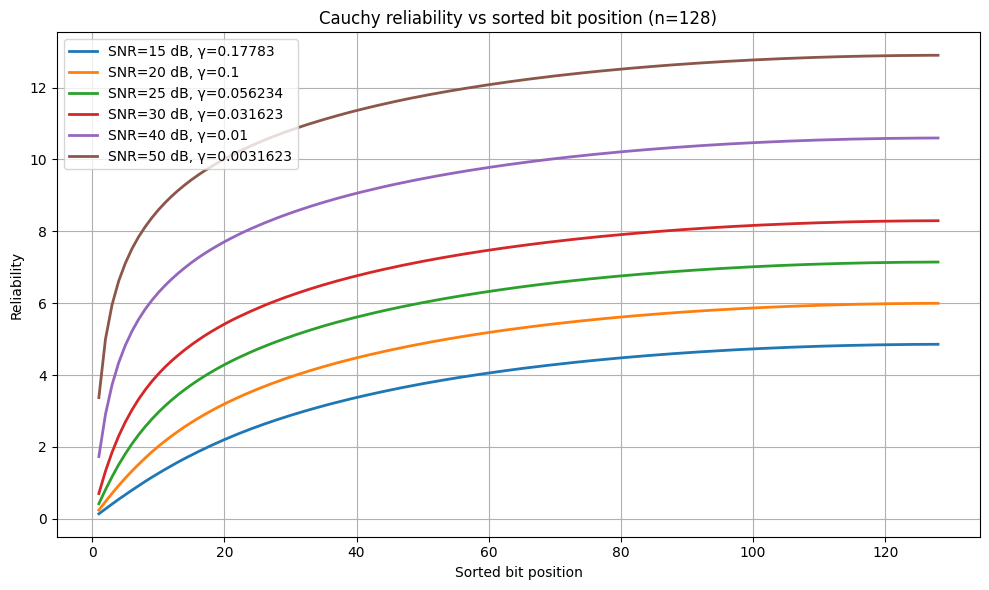

{15: {'gamma': 0.1778279410038923,
  'x': array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
          14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
          27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
          40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
          53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
          66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
          79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
          92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
         105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
         118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128]),
  'Gamma_mean': array([0.13779098, 0.27402249, 0.40851971, 0.54172206, 0.66858559,
         0.79376114, 0.91619876, 1.03647518, 1.15212354, 1.2630739 ,
         1.37207147, 1.47683991, 1.57906284, 1.6770895 , 1.77110879,
       

In [ ]:
# Repeat reliability curve generation for very high SNR values (15–50 dB).
# At high SNR (small gamma), the Cauchy tail is thin and most bits are highly
# reliable — the profile rises steeply.  This call checks behaviour in the
# low-noise regime where decoding is nearly trivial.

cauchy_reliability_curves(128,20000,[15, 20, 25, 30, 40, 50])

# Different Types of Approximations

##Cauchy Reliabililty fit

SNR = 0 dB, gamma = 1

linear
params: [1.77872144 0.26979118]
R^2: 0.9406780124682691

quadratic
params: [-1.72861097  3.52083718 -0.0250982 ]
R^2: 0.9998917322270849

rational a*x/(b+x)
params: [3.50728691 0.87984713]
R^2: 0.9941556557060491

sat exp a*(1-exp(-b*x))
params: [2.27421813 1.6588473 ]
R^2: 0.9964437515690671

atan a*atan(b*x)
params: [1.66220535 1.97027139]
R^2: 0.9982416003656709


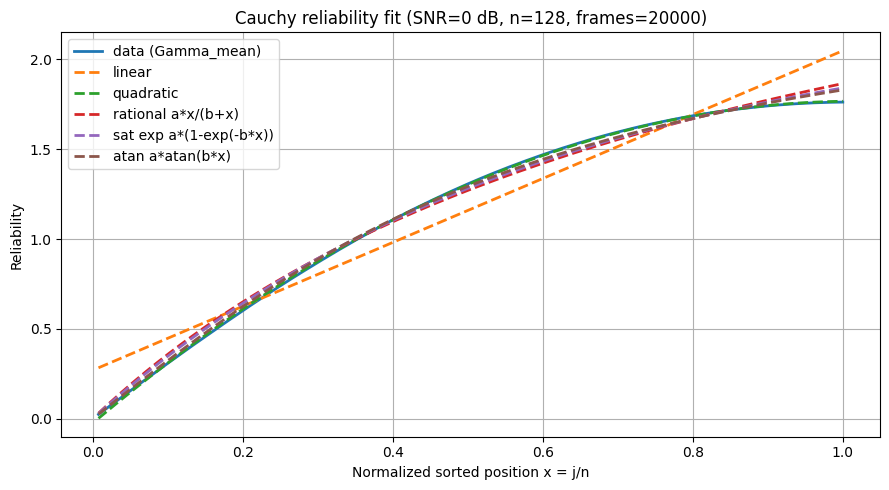

In [ ]:
# =========================================================================
# Cauchy Reliability Fit — Multiple Approximation Models
#
# PURPOSE:
#   Fit and compare several closed-form approximations to the empirical
#   sorted-reliability curve E[|LLR|_(j)] as a function of normalised rank
#   x = j/n in (0,1].  The goal is to find a compact formula that could be
#   used to replace the Monte Carlo lookup table in a hardware decoder.
#
# MODELS COMPARED:
#   Linear:    y = a*x + b                (1 degree of freedom in shape)
#   Quadratic: y = a*x^2 + b*x + c        (2 d.o.f.)
#   Rational:  y = a*x / (b+x)            (saturating concave, 2 d.o.f.)
#   Sat-Exp:   y = a*(1 - exp(-b*x))      (saturating concave, 2 d.o.f.)
#   Arctan:    y = a*arctan(b*x)          (saturating concave, 2 d.o.f.)
#
# GOODNESS-OF-FIT METRIC:
#   R^2 = 1 - SS_res/SS_tot.  R^2 close to 1 means the model explains
#   most of the variance.  For ORBGRAND purposes, ordering preservation
#   matters more than raw R^2, but R^2 is a useful screening metric.
#
# NOTE: cauchy_gamma_mean() normalises the rank to x = j/n in (0,1]
#   so that fitted coefficients are scale-independent across code lengths.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

# --- 1) Generate the Cauchy reliability curve (same as your MATLAB) ---
def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
    s = 1 - 2 * x_bits

    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    Gamma_sorted = np.sort(Gamma, axis=0)
    Gamma_mean = Gamma_sorted.mean(axis=1)

    # normalize rank to [0,1]
    x = np.arange(1, n + 1) / n
    y = Gamma_mean
    return gamma, x, y

# --- 2) Fit helpers ---
def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

# --- 3) Linear + Quadratic (no SciPy needed) ---
def fit_linear(x, y):
    p = np.polyfit(x, y, 1)          # y = a x + b
    yhat = np.polyval(p, x)
    return ("linear", p, yhat)

def fit_quadratic(x, y):
    p = np.polyfit(x, y, 2)          # y = a x^2 + b x + c
    yhat = np.polyval(p, x)
    return ("quadratic", p, yhat)

# --- 4) Nonlinear fits (SciPy curve_fit) ---
def fit_nonlinear_models(x, y):
    try:
        from scipy.optimize import curve_fit
    except ImportError:
        print("SciPy not installed. Skipping nonlinear fits (rational/exp/atan).")
        return []

    # models
    def rational(x, a, b):     # a*x/(b+x)
        return (a * x) / (b + x)

    def sat_exp(x, a, b):      # a*(1-exp(-b*x))
        return a * (1 - np.exp(-b * x))

    def atan_model(x, a, b):   # a*atan(b*x)
        return a * np.arctan(b * x)

    fits = []

    # rational
    popt, _ = curve_fit(rational, x, y, p0=[y.max(), 0.3], bounds=(0, np.inf), maxfev=10000)
    fits.append(("rational a*x/(b+x)", popt, rational(x, *popt)))

    # sat exp
    popt, _ = curve_fit(sat_exp, x, y, p0=[y.max(), 2.0], bounds=(0, np.inf), maxfev=10000)
    fits.append(("sat exp a*(1-exp(-b*x))", popt, sat_exp(x, *popt)))

    # atan
    popt, _ = curve_fit(atan_model, x, y, p0=[y.max(), 2.0], bounds=(0, np.inf), maxfev=10000)
    fits.append(("atan a*atan(b*x)", popt, atan_model(x, *popt)))

    return fits

# --- 5) Run everything for one SNR and plot ---
def run_regression_demo(snrdb=0, n=128, Nframes=20000, seed=0):
    gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

    fits = []
    fits.append(fit_linear(x, y))
    fits.append(fit_quadratic(x, y))
    fits.extend(fit_nonlinear_models(x, y))

    # print metrics
    print(f"SNR = {snrdb} dB, gamma = {gamma:.5g}")
    for name, params, yhat in fits:
        print(f"\n{name}")
        print("params:", params)
        print("R^2:", r2_score(y, yhat))

    # plot
    plt.figure(figsize=(9,5))
    plt.plot(x, y, linewidth=2, label="data (Gamma_mean)")
    for name, params, yhat in fits:
        plt.plot(x, yhat, linestyle="--", linewidth=2, label=name)
    plt.xlabel("Normalized sorted position x = j/n")
    plt.ylabel("Reliability")
    plt.title(f"Cauchy reliability fit (SNR={snrdb} dB, n={n}, frames={Nframes})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example:
run_regression_demo(snrdb=0)

##Quadratic Approx


SNR=-10 dB, gamma=3.1623
Quadratic: y = -0.522758 x^2 + 1.169190 x + -0.014428
R^2 = 0.999422

SNR=0 dB, gamma=1
Quadratic: y = -1.728611 x^2 + 3.520837 x + -0.025098
R^2 = 0.999892

SNR=4 dB, gamma=0.63096
Quadratic: y = -2.720670 x^2 + 5.172356 x + 0.004107
R^2 = 0.999834

SNR=7 dB, gamma=0.44668
Quadratic: y = -3.678655 x^2 + 6.631821 x + 0.067515
R^2 = 0.998792

SNR=10 dB, gamma=0.31623
Quadratic: y = -4.737610 x^2 + 8.151993 x + 0.191243
R^2 = 0.995996

SNR=12 dB, gamma=0.25119
Quadratic: y = -5.454355 x^2 + 9.142183 x + 0.314139
R^2 = 0.992865

SNR=15 dB, gamma=0.17783
Quadratic: y = -6.478452 x^2 + 10.518710 x + 0.564601
R^2 = 0.986224

SNR=20 dB, gamma=0.1
Quadratic: y = -7.930019 x^2 + 12.405870 x + 1.155824
R^2 = 0.970512


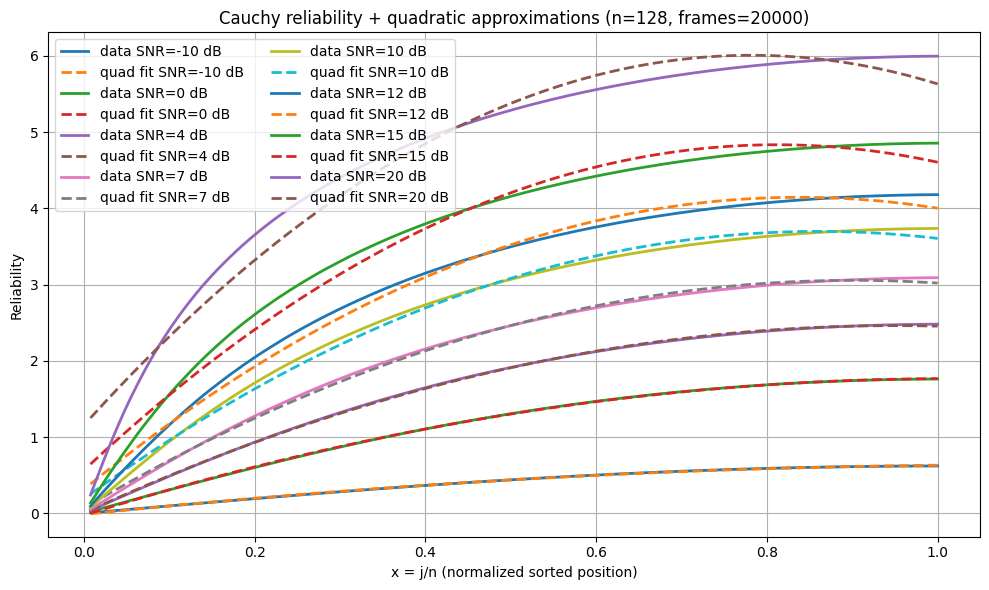

In [ ]:
# =========================================================================
# Quadratic Approximation of the Cauchy Reliability Profile
#
# PURPOSE:
#   Fits a degree-2 polynomial  y = a*x^2 + b*x + c  to the average
#   sorted-reliability curve for multiple SNR/gamma values.
#
# WHY QUADRATIC?
#   The reliability profile rises from zero, curves through a shoulder, and
#   then levels off at high rank (Cauchy outliers).  A quadratic can capture
#   the overall shape with just 3 parameters, though it cannot model the
#   non-monotone or flat tail behaviour at very high gamma.
#
# OUTPUT:
#   For each SNR: prints coefficients and R^2; plots data vs fit.
#   one_plot=True overlays all SNRs on one figure for easy comparison.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    # bits and BPSK mapping: 0->+1, 1->-1
    x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
    s = 1 - 2 * x_bits

    # Cauchy noise: gamma * tan(pi*(U-0.5))
    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    # Cauchy LLR and reliability
    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    # sort per trial and average
    Gamma_sorted = np.sort(Gamma, axis=0)
    Gamma_mean = Gamma_sorted.mean(axis=1)

    x = np.arange(1, n + 1) / n  # normalized rank
    return gamma, x, Gamma_mean

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

def quadratic_approx_for_snrs(SNRdB_list=(-10, 0, 4, 7), n=128, Nframes=20000, seed=0, one_plot=True):
    fits = {}  # snrdb -> dict(gamma, coeffs, r2)

    if one_plot:
        plt.figure(figsize=(10,6))

    for snrdb in SNRdB_list:
        gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

        # Quadratic fit: y = a x^2 + b x + c
        coeffs = np.polyfit(x, y, 2)
        y_fit = np.polyval(coeffs, x)
        r2 = r2_score(y, y_fit)

        fits[snrdb] = {"gamma": gamma, "coeffs": coeffs, "r2": r2}

        print(f"\nSNR={snrdb} dB, gamma={gamma:.5g}")
        print(f"Quadratic: y = {coeffs[0]:.6f} x^2 + {coeffs[1]:.6f} x + {coeffs[2]:.6f}")
        print(f"R^2 = {r2:.6f}")

        if one_plot:
            plt.plot(x, y, linewidth=2, label=f"data SNR={snrdb} dB")
            plt.plot(x, y_fit, "--", linewidth=2, label=f"quad fit SNR={snrdb} dB")
        else:
            plt.figure()
            plt.plot(x, y, linewidth=2, label="data")
            plt.plot(x, y_fit, "--", linewidth=2, label="quad fit")
            plt.xlabel("x = j/n (normalized sorted position)")
            plt.ylabel("Reliability")
            plt.title(f"Quadratic fit (Cauchy, SNR={snrdb} dB, γ={gamma:.5g})")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    if one_plot:
        plt.xlabel("x = j/n (normalized sorted position)")
        plt.ylabel("Reliability")
        plt.title(f"Cauchy reliability + quadratic approximations (n={n}, frames={Nframes})")
        plt.grid(True)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    return fits

# Example usage:
fits = quadratic_approx_for_snrs(SNRdB_list=[-10, 0, 4, 7, 10, 12, 15, 20], n=128, Nframes=20000, seed=0, one_plot=True)

##Cubic Approx


SNR=-10 dB, gamma=3.1623
Cubic: y = -0.238832 x^3 + -0.161712 x^2 + 1.023076 x + -0.001919
R^2 = 0.999988

SNR=0 dB, gamma=1
Cubic: y = -0.232403 x^3 + -1.377283 x^2 + 3.378657 x + -0.012926
R^2 = 0.999961

SNR=4 dB, gamma=0.63096
Cubic: y = 0.455656 x^3 + -3.409494 x^2 + 5.451120 x + -0.019759
R^2 = 0.999973

SNR=7 dB, gamma=0.44668
Cubic: y = 1.623983 x^3 + -6.133661 x^2 + 7.625351 x + -0.017545
R^2 = 0.999985

SNR=10 dB, gamma=0.31623
Cubic: y = 3.421232 x^3 + -9.909550 x^2 + 10.245054 x + 0.012048
R^2 = 0.999865

SNR=12 dB, gamma=0.25119
Cubic: y = 4.906048 x^3 + -12.870919 x^2 + 12.143634 x + 0.057173
R^2 = 0.999566

SNR=15 dB, gamma=0.17783
Cubic: y = 7.369671 x^3 + -17.619323 x^2 + 15.027371 x + 0.178597
R^2 = 0.998480

SNR=20 dB, gamma=0.1
Cubic: y = 11.585297 x^3 + -25.443729 x^2 + 19.493591 x + 0.549015
R^2 = 0.994074


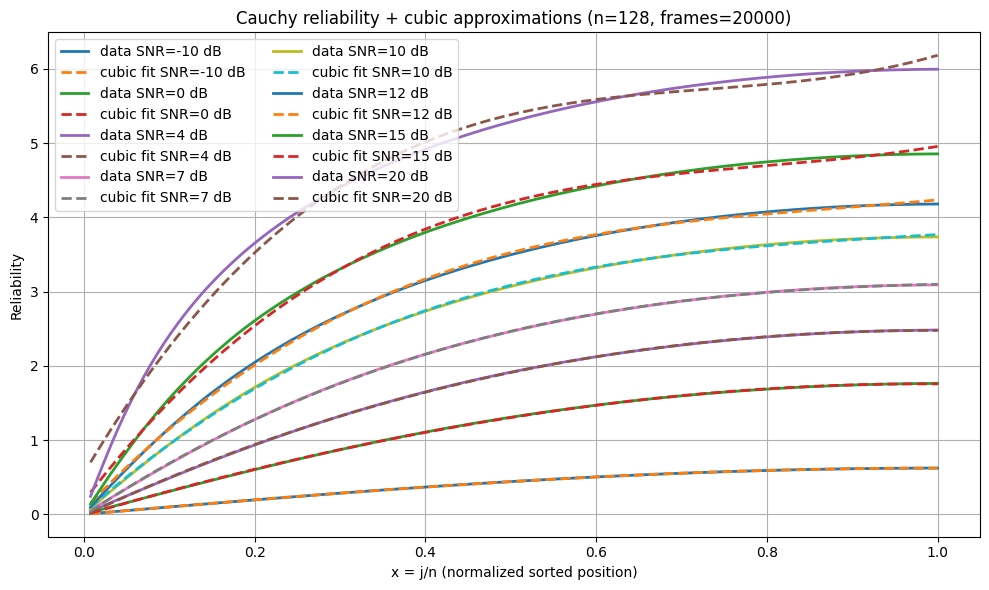

In [ ]:
# =========================================================================
# Cubic Approximation of the Cauchy Reliability Profile
#
# PURPOSE:
#   Fits a degree-3 polynomial  y = a*x^3 + b*x^2 + c*x + d  to the
#   average sorted-reliability curve.  Adds one more degree of freedom
#   over the quadratic fit, allowing the model to better track the
#   inflection point in the reliability curve.
#
# NOTE: Higher-degree polynomials can overfit at the boundaries (x near 0
#   or 1) if the curve is noisy.  Compare R^2 of cubic vs quadratic to
#   assess whether the extra term is worthwhile.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    # bits and BPSK mapping: 0->+1, 1->-1
    x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
    s = 1 - 2 * x_bits

    # Cauchy noise: gamma * tan(pi*(U-0.5))
    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    # Cauchy LLR and reliability
    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    # sort per trial and average
    Gamma_sorted = np.sort(Gamma, axis=0)
    Gamma_mean = Gamma_sorted.mean(axis=1)

    x = np.arange(1, n + 1) / n  # normalized rank
    return gamma, x, Gamma_mean

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

def cubic_approx_for_snrs(SNRdB_list=(-10, 0, 4, 7), n=128, Nframes=20000, seed=0, one_plot=True):
    fits = {}  # snrdb -> dict(gamma, coeffs, r2)

    if one_plot:
        plt.figure(figsize=(10,6))

    for snrdb in SNRdB_list:
        gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

        # Cubic fit: y = a x^3 + b x^2 + c x + d
        coeffs = np.polyfit(x, y, 3)
        y_fit = np.polyval(coeffs, x)
        r2 = r2_score(y, y_fit)

        fits[snrdb] = {"gamma": gamma, "coeffs": coeffs, "r2": r2}

        print(f"\nSNR={snrdb} dB, gamma={gamma:.5g}")
        print(f"Cubic: y = {coeffs[0]:.6f} x^3 + {coeffs[1]:.6f} x^2 + {coeffs[2]:.6f} x + {coeffs[3]:.6f}")
        print(f"R^2 = {r2:.6f}")

        if one_plot:
            plt.plot(x, y, linewidth=2, label=f"data SNR={snrdb} dB")
            plt.plot(x, y_fit, "--", linewidth=2, label=f"cubic fit SNR={snrdb} dB")
        else:
            plt.figure()
            plt.plot(x, y, linewidth=2, label="data")
            plt.plot(x, y_fit, "--", linewidth=2, label="cubic fit")
            plt.xlabel("x = j/n (normalized sorted position)")
            plt.ylabel("Reliability")
            plt.title(f"Cubic fit (Cauchy, SNR={snrdb} dB, γ={gamma:.5g})")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    if one_plot:
        plt.xlabel("x = j/n (normalized sorted position)")
        plt.ylabel("Reliability")
        plt.title(f"Cauchy reliability + cubic approximations (n={n}, frames={Nframes})")
        plt.grid(True)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    return fits

# Example usage:
fits = cubic_approx_for_snrs(SNRdB_list=[-10, 0, 4, 7, 10, 12, 15, 20], n=128, Nframes=20000, seed=0, one_plot=True)

##BiQuadratic Approx


SNR=-10 dB, gamma=3.1623
BiQuadratic: y = 0.134693 x^4 + -0.510323 x^3 + 0.014643 x^2 + 0.983219 x + 0.000160
R^2 = 1.000000

SNR=0 dB, gamma=1
BiQuadratic: y = 0.673518 x^4 + -1.589963 x^3 + -0.495446 x^2 + 3.179357 x + -0.002531
R^2 = 0.999997

SNR=4 dB, gamma=0.63096
BiQuadratic: y = 0.675395 x^4 + -0.905686 x^3 + -2.525200 x^2 + 5.251265 x + -0.009336
R^2 = 0.999992

SNR=7 dB, gamma=0.44668
BiQuadratic: y = -0.153349 x^4 + 1.933077 x^3 + -6.334441 x^2 + 7.670728 x + -0.019911
R^2 = 0.999985

SNR=10 dB, gamma=0.31623
BiQuadratic: y = -2.435800 x^4 + 8.330890 x^3 + -13.098743 x^2 + 10.965827 x + -0.025543
R^2 = 0.999989

SNR=12 dB, gamma=0.25119
BiQuadratic: y = -4.895790 x^4 + 14.774125 x^3 + -19.280977 x^2 + 13.592337 x + -0.018382
R^2 = 0.999990

SNR=15 dB, gamma=0.17783
BiQuadratic: y = -9.966129 x^4 + 27.457650 x^3 + -30.667976 x^2 + 17.976427 x + 0.024793
R^2 = 0.999902

SNR=20 dB, gamma=0.1
BiQuadratic: y = -20.910273 x^4 + 53.732566 x^3 + -52.821550 x^2 + 25.681105 x + 0.226

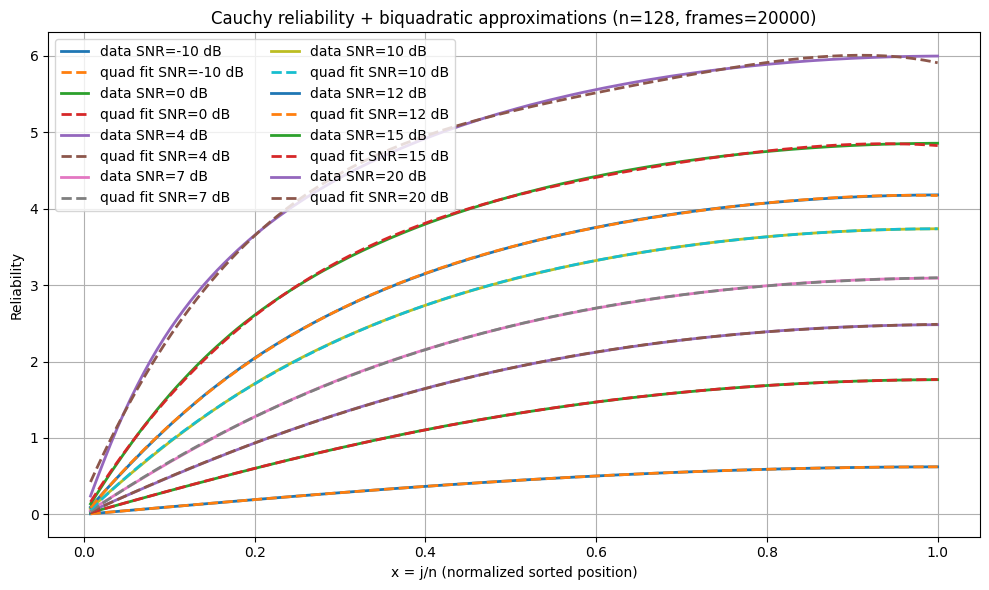

In [ ]:
# =========================================================================
# Biquadratic (Degree-4) Approximation of the Cauchy Reliability Profile
#
# PURPOSE:
#   Fits a degree-4 polynomial  y = a*x^4 + b*x^3 + c*x^2 + d*x + e.
#   Four degrees of freedom allow tracking of both the initial rise and
#   the plateau/outlier region at high rank.
#
# CAUTION: The call at the bottom uses quadratic_approx_for_snrs() instead
#   of biquadratic_approx_for_snrs() — this appears to be a copy-paste
#   leftover.  Run biquadratic_approx_for_snrs() directly to get the
#   degree-4 results.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    # bits and BPSK mapping: 0->+1, 1->-1
    x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
    s = 1 - 2 * x_bits

    # Cauchy noise: gamma * tan(pi*(U-0.5))
    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    # Cauchy LLR and reliability
    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    # sort per trial and average
    Gamma_sorted = np.sort(Gamma, axis=0)
    Gamma_mean = Gamma_sorted.mean(axis=1)

    x = np.arange(1, n + 1) / n  # normalized rank
    return gamma, x, Gamma_mean

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

def biquadratic_approx_for_snrs(SNRdB_list=(-10, 0, 4, 7), n=128, Nframes=20000, seed=0, one_plot=True):
    fits = {}  # snrdb -> dict(gamma, coeffs, r2)

    if one_plot:
        plt.figure(figsize=(10,6))

    for snrdb in SNRdB_list:
        gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

        # Biquadratic fit: y = a x^4 + b x^3 + c x^2 + d x + e
        coeffs = np.polyfit(x, y, 4)
        y_fit = np.polyval(coeffs, x)
        r2 = r2_score(y, y_fit)

        fits[snrdb] = {"gamma": gamma, "coeffs": coeffs, "r2": r2}

        print(f"\nSNR={snrdb} dB, gamma={gamma:.5g}")
        print(f"BiQuadratic: y = {coeffs[0]:.6f} x^4 + {coeffs[1]:.6f} x^3 + {coeffs[2]:.6f} x^2 + {coeffs[3]:.6f} x + {coeffs[4]:.6f}")
        print(f"R^2 = {r2:.6f}")

        if one_plot:
            plt.plot(x, y, linewidth=2, label=f"data SNR={snrdb} dB")
            plt.plot(x, y_fit, "--", linewidth=2, label=f"biquad fit SNR={snrdb} dB")
        else:
            plt.figure()
            plt.plot(x, y, linewidth=2, label="data")
            plt.plot(x, y_fit, "--", linewidth=2, label="biquad fit")
            plt.xlabel("x = j/n (normalized sorted position)")
            plt.ylabel("Reliability")
            plt.title(f"BiQuadratic fit (Cauchy, SNR={snrdb} dB, γ={gamma:.5g})")
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    if one_plot:
        plt.xlabel("x = j/n (normalized sorted position)")
        plt.ylabel("Reliability")
        plt.title(f"Cauchy reliability + biquadratic approximations (n={n}, frames={Nframes})")
        plt.grid(True)
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.show()

    return fits

# Example usage:
fits = quadratic_approx_for_snrs(SNRdB_list=[-10, 0, 4, 7, 10, 12, 15, 20], n=128, Nframes=20000, seed=0, one_plot=True)

##Arctan Fit

SNR=-10 dB, γ=3.1623 → a=0.62580, b=1.74699, c=-0.01125, R²=0.998373
SNR=0 dB, γ=1 → a=1.65496, b=2.06900, c=-0.02986, R²=0.998581
SNR=4 dB, γ=0.63096 → a=2.20397, b=2.40998, c=-0.03499, R²=0.998826
SNR=7 dB, γ=0.44668 → a=2.61502, b=2.77843, c=-0.02799, R²=0.999125
SNR=10 dB, γ=0.31623 → a=3.00995, b=3.23846, c=-0.00432, R²=0.999420
SNR=15 dB, γ=0.17783 → a=3.62228, b=4.16763, c=0.08993, R²=0.999536
SNR=20 dB, γ=0.1 → a=4.15818, b=5.24069, c=0.29228, R²=0.998707
SNR=50 dB, γ=0.0031623 → a=5.63226, b=9.64674, c=4.54835, R²=0.982649


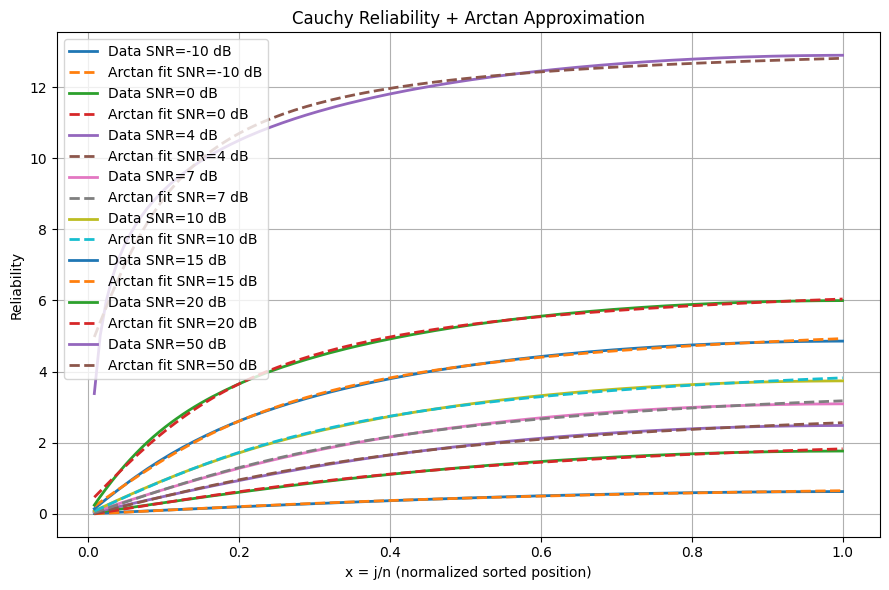

In [ ]:
# =========================================================================
# Arctan Approximation of the Cauchy Reliability Profile
#
# MODEL:  y = a * arctan(b*x) + c
#
# PURPOSE:
#   The arctan function is naturally concave, rises from zero, and saturates
#   as x -> inf.  This makes it a physically motivated model for the
#   reliability profile, which also starts near zero and flattens at high rank.
#
# FITTING:
#   scipy.optimize.curve_fit is used (Levenberg-Marquardt / trust-region).
#   Initial guess p0 = [y_max, 2, 0]; bounds enforce a, b >= 0.
#
# PARAMETERS:
#   a: amplitude (controls the saturation level)
#   b: rate (controls how fast the curve rises with x)
#   c: vertical offset (should be near 0 since reliability -> 0 at rank 1)
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- Generate Cauchy reliability ----------
def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    x_bits = rng.integers(0, 2, size=(n, Nframes))
    s = 1 - 2 * x_bits

    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    Gamma_sorted = np.sort(Gamma, axis=0)
    Gamma_mean = Gamma_sorted.mean(axis=1)

    x = np.arange(1, n + 1) / n
    return gamma, x, Gamma_mean

# ---------- Arctan model ----------
def atan_model(x, a, b, c):
    return a * np.arctan(b * x) + c

def r2_score(y, yhat):
    return 1 - np.sum((y - yhat) ** 2) / np.sum((y - np.mean(y)) ** 2)

# ---------- Fit and plot all SNRs together ----------
def fit_atan_same_plot(SNRdB_list=(-10, 0, 4, 7), n=128, Nframes=20000, seed=0):

    plt.figure(figsize=(9,6))

    for snrdb in SNRdB_list:
        gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

        p0 = [y.max(), 2.0, 0.0]
        bounds = ([0, 0, -np.inf], [np.inf, np.inf, np.inf])

        popt, _ = curve_fit(atan_model, x, y, p0=p0, bounds=bounds, maxfev=20000)
        yhat = atan_model(x, *popt)
        r2 = r2_score(y, yhat)

        a, b, c = popt
        print(f"SNR={snrdb} dB, γ={gamma:.5g} → a={a:.5f}, b={b:.5f}, c={c:.5f}, R²={r2:.6f}")

        # plot data (solid)
        plt.plot(x, y, linewidth=2, label=f"Data SNR={snrdb} dB")

        # plot fit (dashed)
        plt.plot(x, yhat, "--", linewidth=2, label=f"Arctan fit SNR={snrdb} dB")

    plt.xlabel("x = j/n (normalized sorted position)")
    plt.ylabel("Reliability")
    plt.title("Cauchy Reliability + Arctan Approximation")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Run
fit_atan_same_plot(SNRdB_list=[-10, 0, 4, 7, 10, 15, 20, 50])

##Log Fit

SNR=-10 dB, γ=3.1623 → a=0.47950, b=3.24324, c=-0.03156, R²=0.994647
SNR=0 dB, γ=1 → a=1.13195, b=4.74835, c=-0.10602, R²=0.993793
SNR=4 dB, γ=0.63096 → a=1.36924, b=6.77969, c=-0.17185, R²=0.992999
SNR=7 dB, γ=0.44668 → a=1.49228, b=9.59424, c=-0.24116, R²=0.992396
SNR=10 dB, γ=0.31623 → a=1.57485, b=14.25930, c=-0.33194, R²=0.991874
SNR=15 dB, γ=0.17783 → a=1.65968, b=29.47197, c=-0.54475, R²=0.991113
SNR=20 dB, γ=0.1 → a=1.70299, b=67.10268, c=-0.88621, R²=0.990715


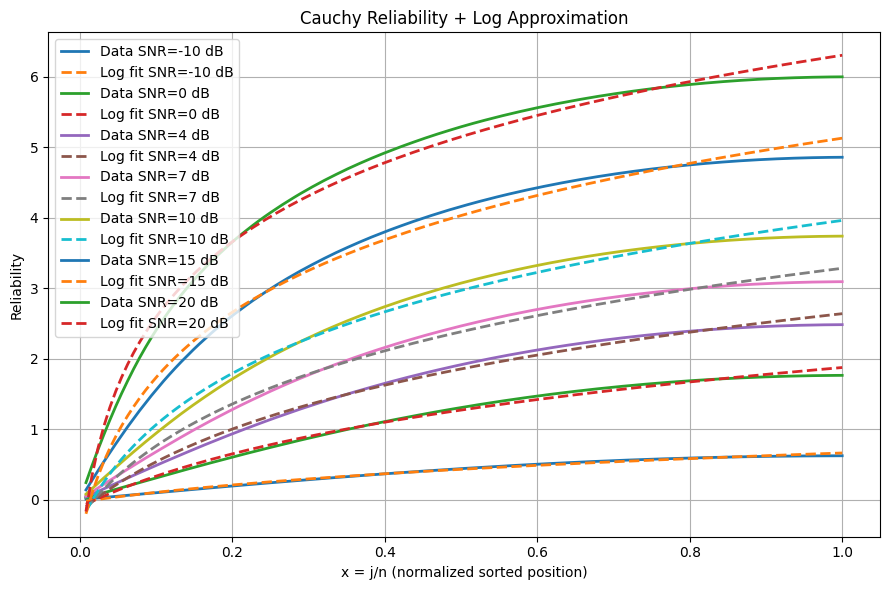

In [ ]:
# =========================================================================
# Logarithmic Approximation of the Cauchy Reliability Profile
#
# MODEL:  y = a * log(1 + b*x) + c
#
# PURPOSE:
#   log(1+b*x) is another concave, monotone-increasing function that
#   starts at 0 and grows more slowly than linearly.  It is compared
#   to the arctan model to see which better tracks the shape of the
#   Cauchy reliability profile across a wide range of SNR values.
#
# NOTE: The function is named fit_atan_same_plot (copied from the arctan
#   cell) but implements the log model internally.  The plot title and
#   labels correctly say 'Log Approximation'.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- Generate Cauchy reliability ----------
def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    x_bits = rng.integers(0, 2, size=(n, Nframes))
    s = 1 - 2 * x_bits

    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    Gamma_sorted = np.sort(Gamma, axis=0)
    Gamma_mean = Gamma_sorted.mean(axis=1)

    x = np.arange(1, n + 1) / n
    return gamma, x, Gamma_mean

# ---------- Arctan model ----------
def ln_model(x, a, b, c):
    #y=alog(1+bx)+c
    return a * np.log(1+ b*x) +c

def r2_score(y, yhat):
    return 1 - np.sum((y - yhat) ** 2) / np.sum((y - np.mean(y)) ** 2)

# ---------- Fit and plot all SNRs together ----------
def fit_atan_same_plot(SNRdB_list=(-10, 0, 4, 7), n=128, Nframes=20000, seed=0):

    plt.figure(figsize=(9,6))

    for snrdb in SNRdB_list:
        gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

        p0 = [y.max(), 2.0, 0.0]
        bounds = ([0, 0, -np.inf], [np.inf, np.inf, np.inf])

        popt, _ = curve_fit(ln_model, x, y, p0=p0, bounds=bounds, maxfev=20000)
        yhat = ln_model(x, *popt)
        r2 = r2_score(y, yhat)

        a, b, c = popt
        print(f"SNR={snrdb} dB, γ={gamma:.5g} → a={a:.5f}, b={b:.5f}, c={c:.5f}, R²={r2:.6f}")

        # plot data (solid)
        plt.plot(x, y, linewidth=2, label=f"Data SNR={snrdb} dB")

        # plot fit (dashed)
        plt.plot(x, yhat, "--", linewidth=2, label=f"Log fit SNR={snrdb} dB")

    plt.xlabel("x = j/n (normalized sorted position)")
    plt.ylabel("Reliability")
    plt.title("Cauchy Reliability + Log Approximation")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Run
fit_atan_same_plot(SNRdB_list=[-10, 0, 4, 7, 10, 15, 20])


SNR=-10 dB, gamma=3.1623
params: a=0.84285, b=1.16686, c=0.000204728
TEST  RMSE=0.0397321 | MAE=0.0261082 | R²=0.906653

SNR=0 dB, gamma=1
params: a=1.9105, b=1.62582, c=0.000174901
TEST  RMSE=0.0648975 | MAE=0.039215 | R²=0.965024

SNR=4 dB, gamma=0.63096
params: a=2.30016, b=2.14444, c=0.000622811
TEST  RMSE=0.0396851 | MAE=0.027886 | R²=0.992415

SNR=7 dB, gamma=0.44668
params: a=2.62078, b=2.64317, c=0.00156198
TEST  RMSE=0.037354 | MAE=0.0318251 | R²=0.994949


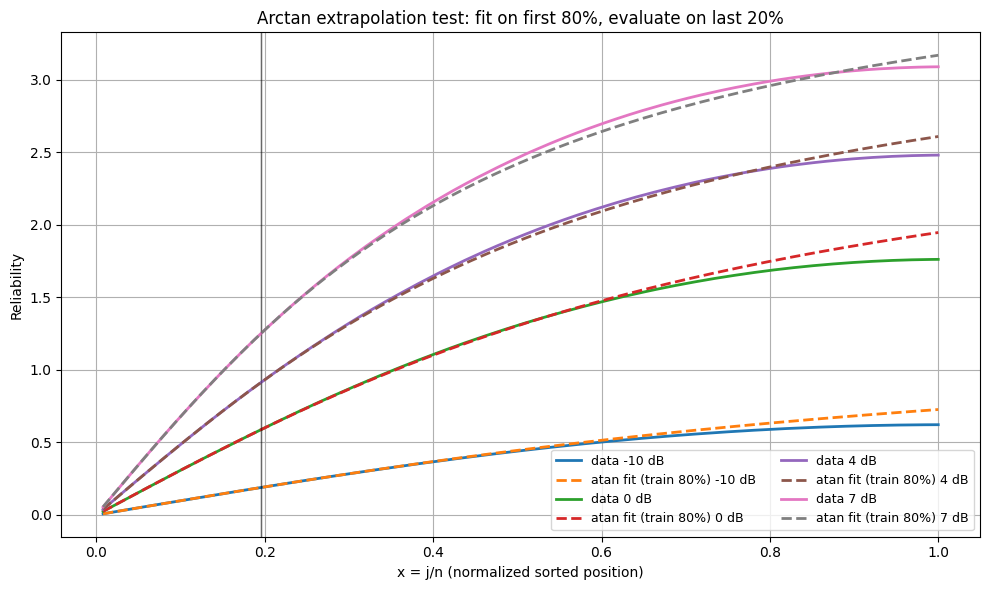

In [ ]:
# =========================================================================
# Arctan Extrapolation Test
#
# PURPOSE:
#   Evaluates how well the arctan model generalises beyond its training
#   region.  The model is fitted on the FIRST train_frac fraction of the
#   sorted-rank axis (e.g. x in [0, 0.2]) and then evaluated on the
#   remaining x in (0.2, 1].  This tests whether the arctan's saturation
#   behaviour is correctly captured from just the rising segment.
#
# METRICS REPORTED ON THE TEST (extrapolation) REGION ONLY:
#   RMSE : root-mean-squared error
#   MAE  : mean absolute error
#   R^2  : coefficient of determination
#
# WHY THIS MATTERS:
#   In hardware, it may be cheaper to measure reliability only for a subset
#   of received values and extrapolate.  Good extrapolation means the model
#   can be calibrated on a small sample and applied to the full rank range.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- Generate Cauchy reliability curve ----------
def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
    s = 1 - 2 * x_bits

    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    Gamma_sorted = np.sort(Gamma, axis=0)
    y = Gamma_sorted.mean(axis=1)

    x = np.arange(1, n + 1) / n  # normalized rank
    return gamma, x, y

# ---------- Arctan model ----------
def atan_model(x, a, b, c):
    return a * np.arctan(b * x) + c

# ---------- Metrics ----------
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def r2(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

# ---------- Extrapolation test ----------
def extrapolation_test_arctan(
    SNRdB_list=(-10, 0, 4, 7),
    train_frac=0.2,
    n=128,
    Nframes=20000,
    seed=0
):
    plt.figure(figsize=(10,6))

    for snrdb in SNRdB_list:
        gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

        split = int(np.floor(train_frac * len(x)))
        x_train, y_train = x[:split], y[:split]
        x_test,  y_test  = x[split:], y[split:]

        # Fit ONLY on training part
        p0 = [y_train.max(), 2.0, 0.0]
        bounds = ([0.0, 0.0, -np.inf], [np.inf, np.inf, np.inf])
        popt, _ = curve_fit(atan_model, x_train, y_train, p0=p0, bounds=bounds, maxfev=20000)

        # Predict on whole curve (incl. test region)
        yhat_all = atan_model(x, *popt)
        yhat_test = atan_model(x_test, *popt)

        # Metrics on the TEST region only (true extrapolation check)
        print(f"\nSNR={snrdb} dB, gamma={gamma:.5g}")
        print(f"params: a={popt[0]:.6g}, b={popt[1]:.6g}, c={popt[2]:.6g}")
        print(f"TEST  RMSE={rmse(y_test, yhat_test):.6g} | MAE={mae(y_test, yhat_test):.6g} | R²={r2(y_test, yhat_test):.6f}")

        # Plot: data (solid) + fit trained on 80% (dashed)
        plt.plot(x, y, linewidth=2, label=f"data {snrdb} dB")
        plt.plot(x, yhat_all, "--", linewidth=2, label=f"atan fit (train 80%) {snrdb} dB")

        # Mark the split point
        plt.axvline(x[split-1], color="k", linewidth=1, alpha=0.2)

    plt.xlabel("x = j/n (normalized sorted position)")
    plt.ylabel("Reliability")
    plt.title("Arctan extrapolation test: fit on first 80%, evaluate on last 20%")
    plt.grid(True)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

# Run
extrapolation_test_arctan(SNRdB_list=[-10, 0, 4, 7], train_frac=0.2)


SNR=-10 dB, gamma=3.1623, split=0.2
Segment 1 (x<= 0.195): y = -0.13214 x^2 + 0.994384 x + 3.91787e-07
Segment 2 (x>  0.195): y = -0.59504 x^2 + 1.26189 x + -0.0406073
Overall R^2 = 0.999924

SNR=0 dB, gamma=1, split=0.2
Segment 1 (x<= 0.195): y = -0.776892 x^2 + 3.16838 x + -0.000963385
Segment 2 (x>  0.195): y = -1.80649 x^2 + 3.61945 x + -0.0523229
Overall R^2 = 0.999998

SNR=4 dB, gamma=0.63096, split=0.2
Segment 1 (x<= 0.195): y = -2.03877 x^2 + 5.09148 x + -0.00223635
Segment 2 (x>  0.195): y = -2.59085 x^2 + 5.00328 x + 0.0531313
Overall R^2 = 0.999925

SNR=7 dB, gamma=0.44668, split=0.2
Segment 1 (x<= 0.195): y = -4.0995 x^2 + 7.23634 x + -0.00389538
Segment 2 (x>  0.195): y = -3.18069 x^2 + 5.99 x + 0.250348
Overall R^2 = 0.999769

SNR=10 dB, gamma=0.31623, split=0.2
Segment 1 (x<= 0.195): y = -8.72047 x^2 + 10.3413 x + -0.00665491
Segment 2 (x>  0.195): y = -3.66977 x^2 + 6.78172 x + 0.578611
Overall R^2 = 0.999579

SNR=20 dB, gamma=0.1, split=0.2
Segment 1 (x<= 0.195): y = 

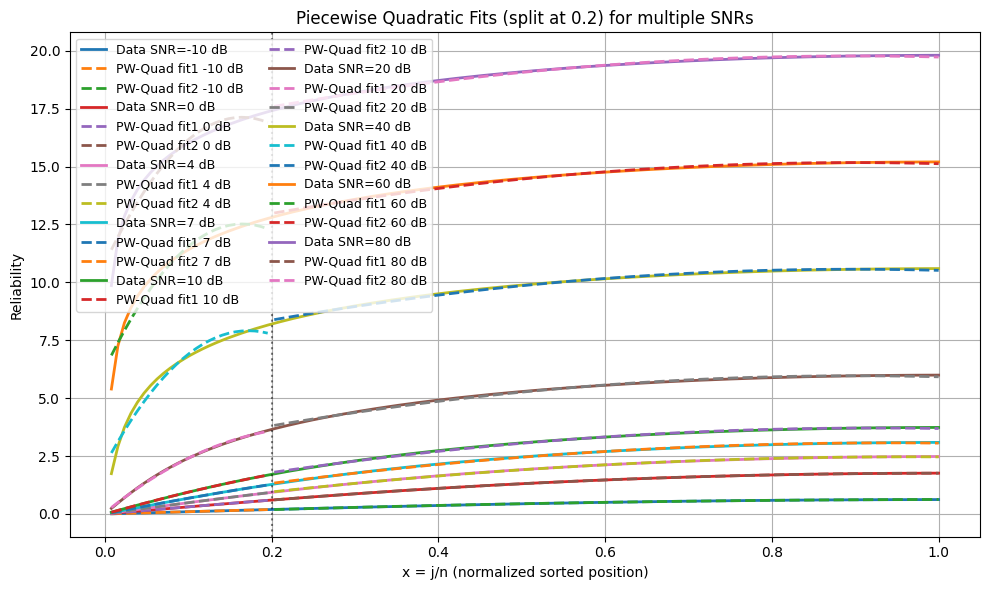

In [ ]:
# =========================================================================
# Piecewise Quadratic Approximation (2 segments)
#
# PURPOSE:
#   Splits the normalised rank axis at split_frac (default 0.2) and fits
#   an independent degree-2 polynomial on each segment.  This allows the
#   model to track both the fast-rising initial region and the flatter tail
#   region independently, at the cost of a discontinuity at the split point.
#
# MODEL (per segment):
#   Segment 1 (x <= split_frac): y = a1*x^2 + b1*x + c1
#   Segment 2 (x >  split_frac): y = a2*x^2 + b2*x + c2
#
# NOTE: No continuity constraint is enforced at the split — the two
#   polynomials are fitted independently.  The overall R^2 is computed
#   over the full curve to allow comparison with single-segment models.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- Generate Cauchy reliability curve ----------
def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
    s = 1 - 2 * x_bits

    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    Gamma_sorted = np.sort(Gamma, axis=0)
    y = Gamma_sorted.mean(axis=1)

    x = np.arange(1, n + 1) / n  # normalized rank
    return gamma, x, y

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

# ---------- Piecewise quadratic fit for multiple SNRs, one plot ----------
def piecewise_quadratic_multi_snr(
    SNRdB_list=(-10, 0, 4, 7),
    split_frac=0.2,
    n=128,
    Nframes=20000,
    seed=0
):
    plt.figure(figsize=(10, 6))
    split_index = int(np.floor(split_frac * n))

    for snrdb in SNRdB_list:
        gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

        # split
        x1, y1 = x[:split_index], y[:split_index]
        x2, y2 = x[split_index:], y[split_index:]

        # quadratic fits on each segment
        p1 = np.polyfit(x1, y1, 2)  # y = a1 x^2 + b1 x + c1
        p2 = np.polyfit(x2, y2, 2)  # y = a2 x^2 + b2 x + c2

        y1_fit = np.polyval(p1, x1)
        y2_fit = np.polyval(p2, x2)
        y_fit = np.concatenate([y1_fit, y2_fit])

        r2 = r2_score(y, y_fit)

        print(f"\nSNR={snrdb} dB, gamma={gamma:.5g}, split={split_frac}")
        print(f"Segment 1 (x<= {x[split_index-1]:.3f}): y = {p1[0]:.6g} x^2 + {p1[1]:.6g} x + {p1[2]:.6g}")
        print(f"Segment 2 (x>  {x[split_index-1]:.3f}): y = {p2[0]:.6g} x^2 + {p2[1]:.6g} x + {p2[2]:.6g}")
        print(f"Overall R^2 = {r2:.6f}")

        # plot data + piecewise fit (same graph)
        plt.plot(x, y, linewidth=2, label=f"Data SNR={snrdb} dB")
        plt.plot(x1, y1_fit, "--", linewidth=2, label=f"PW-Quad fit1 {snrdb} dB")
        plt.plot(x2, y2_fit, "--", linewidth=2, label=f"PW-Quad fit2 {snrdb} dB")

    # split marker
    plt.axvline(split_frac, color="k", linestyle=":", alpha=0.5)

    plt.xlabel("x = j/n (normalized sorted position)")
    plt.ylabel("Reliability")
    plt.title(f"Piecewise Quadratic Fits (split at {split_frac}) for multiple SNRs")
    plt.grid(True)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

# Example run:
piecewise_quadratic_multi_snr(SNRdB_list=[-10, 0, 4, 7, 10, 20, 40, 60, 80], split_frac=0.2, n=128, Nframes=20000, seed=0)


SNR=-10 dB, gamma=3.1623, split=0.2 (x=0.195)
  Segment 1 (arctan): y = a*atan(b*x) + c
    a=3.54836, b=0.280399, c=-9.39036e-06
  Segment 2 (quadratic): y = A*x^2 + B*x + C
    A=-0.59504, B=1.26189, C=-0.0406073
  Overall R^2 = 0.999924

SNR=0 dB, gamma=1, split=0.2 (x=0.195)
  Segment 1 (arctan): y = a*atan(b*x) + c
    a=5.86144, b=0.541605, c=-0.00106445
  Segment 2 (quadratic): y = A*x^2 + B*x + C
    A=-1.80649, B=3.61945, C=-0.0523229
  Overall R^2 = 0.999998

SNR=4 dB, gamma=0.63096, split=0.2 (x=0.195)
  Segment 1 (arctan): y = a*atan(b*x) + c
    a=5.40994, b=0.94634, c=-0.00269065
  Segment 2 (quadratic): y = A*x^2 + B*x + C
    A=-2.59085, B=5.00328, C=0.0531313
  Overall R^2 = 0.999925

SNR=7 dB, gamma=0.44668, split=0.2 (x=0.195)
  Segment 1 (arctan): y = a*atan(b*x) + c
    a=5.05862, b=1.44759, c=-0.00529032
  Segment 2 (quadratic): y = A*x^2 + B*x + C
    A=-3.18069, B=5.99, C=0.250348
  Overall R^2 = 0.999769

SNR=10 dB, gamma=0.31623, split=0.2 (x=0.195)
  Segment

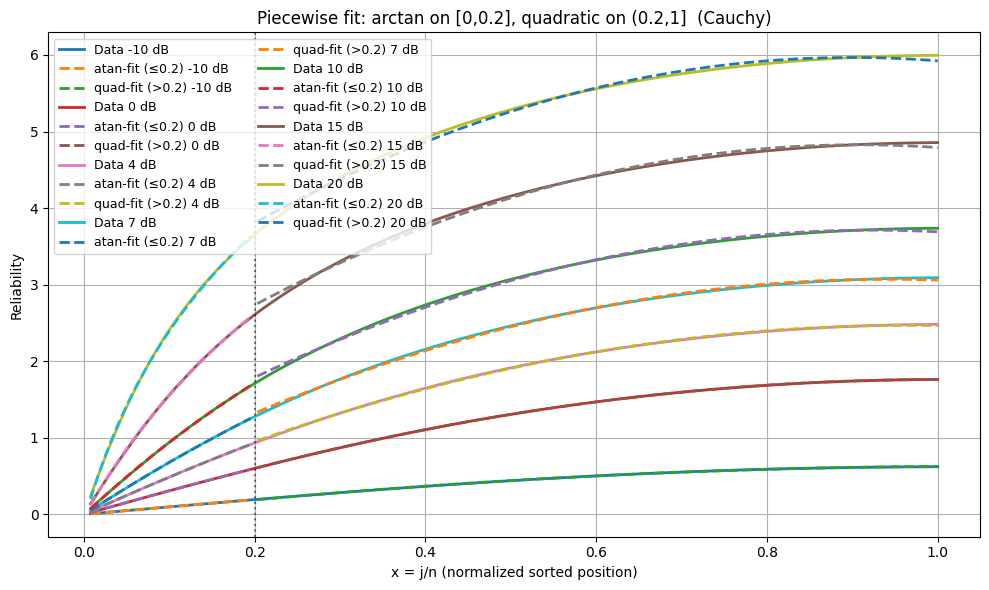

In [ ]:
# =========================================================================
# Hybrid Piecewise Fit: Log/Arctan on [0, split] + Quadratic on (split, 1]
#
# PURPOSE:
#   Combines the physical motivation of the log/arctan model (which naturally
#   rises from zero, matching the reliability behaviour near rank 1) with the
#   flexibility of a quadratic polynomial for the flatter tail region.
#
# STRUCTURE:
#   Segment 1 (x <= split_frac): fit with  y = a*log(1+b*x) + c  (ln_model)
#   Segment 2 (x >  split_frac): fit with  y = A*x^2 + B*x + C
#
# NOTE: The function name references 'arctan' but uses ln_model internally.
#   No continuity is enforced at the split — the two segments are
#   fitted independently.  The overall R^2 summarises the combined fit.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------- Generate Cauchy reliability curve ----------
def cauchy_gamma_mean(n=128, Nframes=20000, snrdb=0, seed=0):
    rng = np.random.default_rng(seed)
    gamma = 10 ** (-snrdb / 20)

    x_bits = rng.integers(0, 2, size=(n, Nframes), dtype=np.int8)
    s = 1 - 2 * x_bits

    U = rng.random(size=(n, Nframes))
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)
    Gamma = np.abs(LLR)

    Gamma_sorted = np.sort(Gamma, axis=0)
    y = Gamma_sorted.mean(axis=1)

    x = np.arange(1, n + 1) / n  # normalized rank in (0,1]
    return gamma, x, y

# ---------- Models / metrics ----------
def atan_model(x, a, b, c):
    return a * np.arctan(b * x) + c

def exp_model(x, a, b, c):
    #y=a(1−e−bx)+c
    return a * (1 - np.exp(-b * x)) + c

def ln_model(x, a, b, c):
    #y=alog(1+bx)+c
    return a * np.log(1+ b*x) +c

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

# ---------- Piecewise: arctan on [0,split], quadratic on (split,1] ----------
def piecewise_atan_then_quadratic_multi_snr(
    SNRdB_list=(-10, 0, 4, 7),
    split_frac=0.2,
    n=128,
    Nframes=20000,
    seed=0,
    plot_data=True
):
    plt.figure(figsize=(10, 6))
    split_idx = int(np.floor(split_frac * n))
    split_x = split_idx / n

    for snrdb in SNRdB_list:
        gamma, x, y = cauchy_gamma_mean(n=n, Nframes=Nframes, snrdb=snrdb, seed=seed)

        x1, y1 = x[:split_idx], y[:split_idx]
        x2, y2 = x[split_idx:], y[split_idx:]

        # --- Fit arctan on first segment ---
        p0 = [y1.max(), 2.0, 0.0]
        bounds = ([0.0, 0.0, -np.inf], [np.inf, np.inf, np.inf])
        popt, _ = curve_fit(ln_model, x1, y1, p0=p0, bounds=bounds, maxfev=30000)
        y1_fit = ln_model(x1, *popt)

        # --- Fit quadratic on second segment ---
        q = np.polyfit(x2, y2, 2)          # y = q0*x^2 + q1*x + q2
        y2_fit = np.polyval(q, x2)

        # Combine piecewise prediction (no continuity constraint)
        y_fit = np.concatenate([y1_fit, y2_fit])
        r2 = r2_score(y, y_fit)

        print(f"\nSNR={snrdb} dB, gamma={gamma:.5g}, split={split_frac} (x={split_x:.3f})")
        print(f"  Segment 1 (arctan): y = a*atan(b*x) + c")
        print(f"    a={popt[0]:.6g}, b={popt[1]:.6g}, c={popt[2]:.6g}")
        print(f"  Segment 2 (quadratic): y = A*x^2 + B*x + C")
        print(f"    A={q[0]:.6g}, B={q[1]:.6g}, C={q[2]:.6g}")
        print(f"  Overall R^2 = {r2:.6f}")

        # Plot: one figure, all SNRs
        if plot_data:
            plt.plot(x, y, linewidth=2, label=f"Data {snrdb} dB")
        plt.plot(x1, y1_fit, "--", linewidth=2, label=f"atan-fit (≤{split_frac}) {snrdb} dB")
        plt.plot(x2, y2_fit, "--", linewidth=2, label=f"quad-fit (>{split_frac}) {snrdb} dB")

    plt.axvline(split_frac, color="k", linestyle=":", alpha=0.5)
    plt.xlabel("x = j/n (normalized sorted position)")
    plt.ylabel("Reliability")
    plt.title(f"Piecewise fit: arctan on [0,{split_frac}], quadratic on ({split_frac},1]  (Cauchy)")
    plt.grid(True)
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

# Example:
piecewise_atan_then_quadratic_multi_snr(SNRdB_list=[-10, 0, 4, 7, 10, 15, 20], split_frac=0.2, n=128, Nframes=20000, seed=0)

# Piecewise Linear Approx

##Two-slope piecewise fit


Best parameters
m1 = 0.8636990481254122
m2 = 0.32130082707992164
split = 0.5658227848101266
SNR = -10
MSE = 0.008%


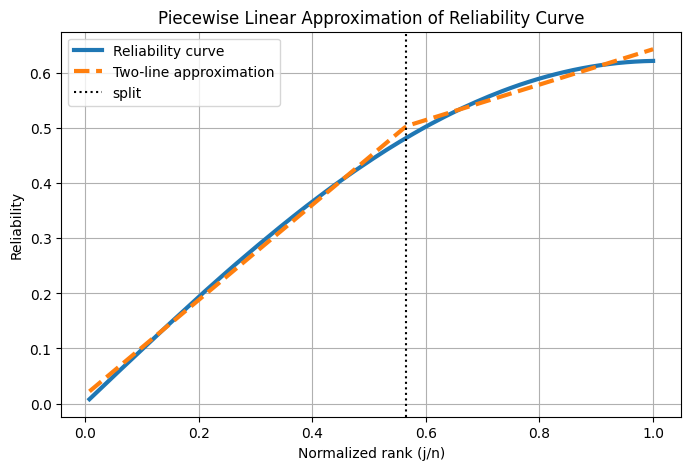

Best parameters
m1 = 1.693539779686705
m2 = 0.6067148344513065
split = 0.5455696202531646
SNR = -4
MSE = 0.034%


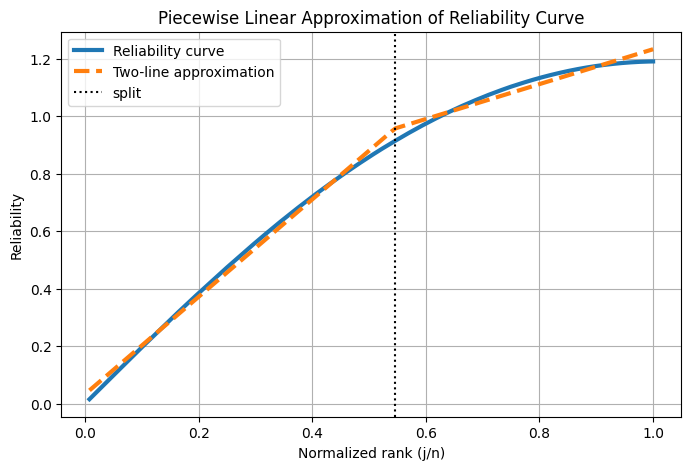

Best parameters
m1 = 3.924526422697812
m2 = 1.178489327643531
split = 0.47468354430379744
SNR = 4
MSE = 0.229%


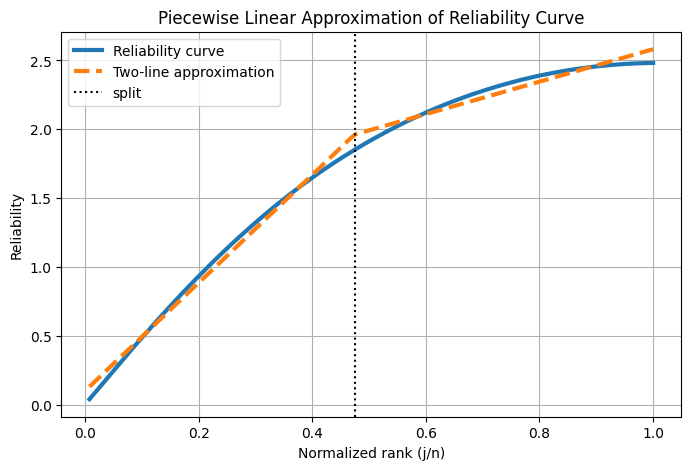

Best parameters
m1 = 5.230943041814092
m2 = 1.4070240428553917
split = 0.4341772151898734
SNR = 7
MSE = 0.449%


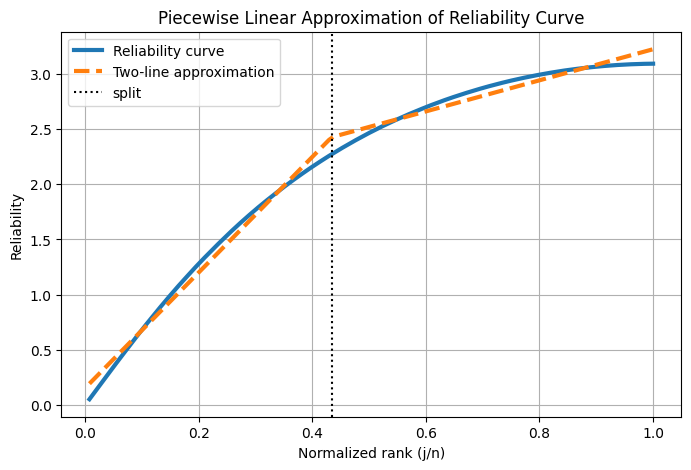

Best parameters
m1 = 6.827314953375871
m2 = 1.6215913624007774
split = 0.39367088607594936
SNR = 10
MSE = 0.799%


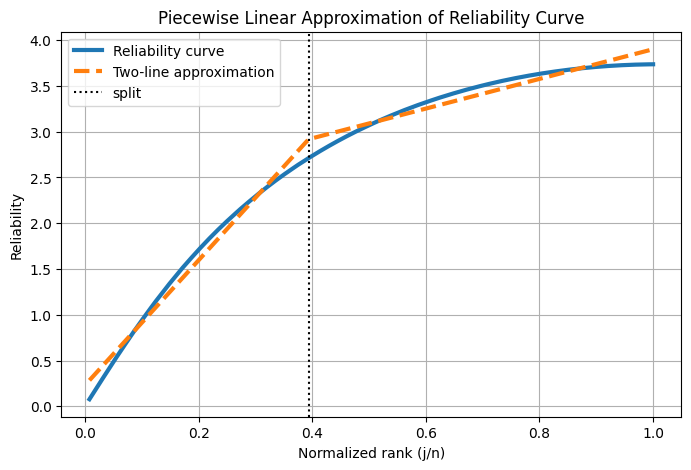

Best parameters
m1 = 10.338188945649222
m2 = 1.9883693569817167
split = 0.3227848101265823
SNR = 15
MSE = 1.793%


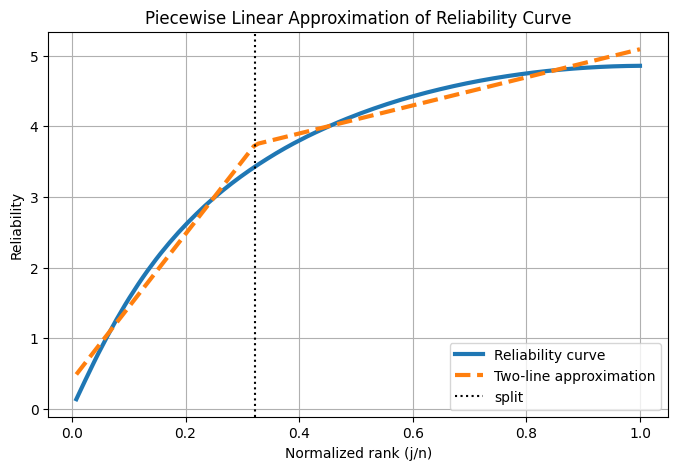

Best parameters
m1 = 14.465543592854404
m2 = 2.246320455258756
split = 0.2721518987341772
SNR = 20
MSE = 3.328%


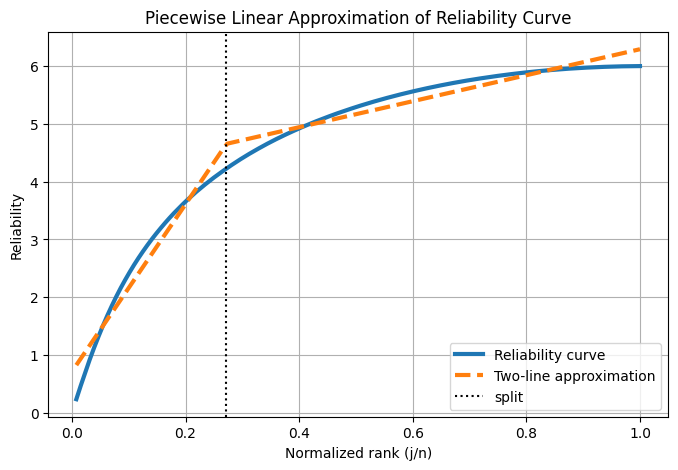

Best parameters
m1 = 35.121021296609186
m2 = 2.9212805924710636
split = 0.1607594936708861
SNR = 50
MSE = 13.355%


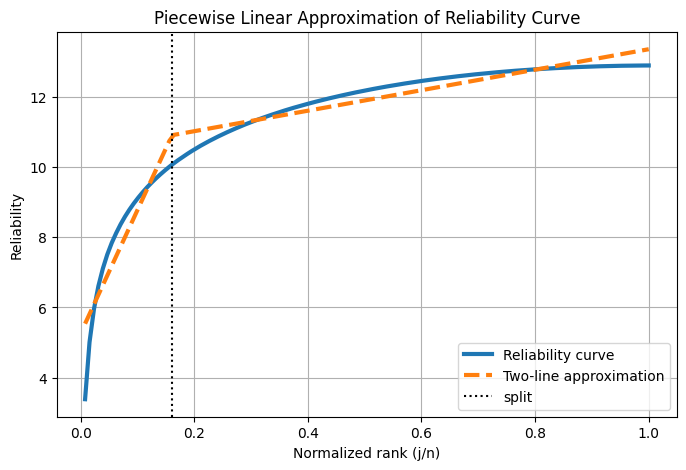

In [ ]:
# =========================================================================
# Two-Slope Continuous Piecewise Linear Fit
#
# PURPOSE:
#   Fits a continuous piecewise linear model with a SINGLE breakpoint t
#   to the empirical Cauchy reliability profile.
#
# MODEL:  y = b + m1*min(x,t) + m2*max(0, x-t)
#   Equivalently: slope m1 on [0,t], slope (m1+m2) on (t, max_x].
#   The intercept b and both slope-hinge coefficients are solved jointly
#   via linear least squares (np.linalg.lstsq) for each candidate t.
#
# BREAKPOINT SEARCH:
#   t is scanned over 80 evenly-spaced values in [0.1, 0.9] (normalised
#   rank).  The breakpoint minimising the sum-of-squared errors (SSE) is
#   selected.  MSE = SSE / n is printed for comparison across SNR values.
#
# NOTE: x = j/n is the normalised rank, so t = 0.2 means the breakpoint
#   is at the 20th-percentile rank bit.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Generate example Cauchy reliability curve
# -------------------------------------------------

def generate_cauchy_curve(n=128, Nframes=20000, snrdb=0):

    gamma = 10 ** (-snrdb / 20)

    x_bits = np.random.randint(0,2,(n,Nframes))
    s = 1 - 2*x_bits

    U = np.random.rand(n,Nframes)
    z = gamma * np.tan(np.pi*(U-0.5))
    r = s + z

    LLR = np.log(1 + ((r-1)/gamma)**2) - np.log(1 + ((r+1)/gamma)**2)

    Gamma = np.abs(LLR)

    Gamma_sorted = np.sort(Gamma,axis=0)

    y = np.mean(Gamma_sorted,axis=1)

    x = np.arange(1,n+1)/n

    return x,y


# -------------------------------------------------
# Two-slope piecewise fit
# -------------------------------------------------

def piecewise_fit(x,y):

    best_sse = np.inf
    best_params = None

    for t in np.linspace(0.1,0.9,80):

        a1 = np.minimum(x,t)
        a2 = np.maximum(0,x-t)

        A = np.column_stack([np.ones_like(x),a1,a2])

        theta,_,_,_ = np.linalg.lstsq(A,y,rcond=None)

        b,m1,m2 = theta

        yhat = A@theta

        sse = np.sum((y-yhat)**2)

        if sse < best_sse:

            best_sse = sse
            best_mse= best_sse/len(x)
            best_params = (b,m1,m2,t,yhat, best_mse)

    return best_params


# -------------------------------------------------
# Run example
# -------------------------------------------------
for snrdb in [-10,-4,4,7,10,15,20,50]:
    x,y = generate_cauchy_curve(snrdb=snrdb)

    b,m1,m2,t,yhat, best_mse = piecewise_fit(x,y)

    print("Best parameters")
    print("m1 =",m1)
    print("m2 =",m2)
    print("split =",t)
    print("SNR =", snrdb)
    print(f"MSE = {best_mse*100:.3f}%")

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------

    plt.figure(figsize=(8,5))

    plt.plot(x,y,label="Reliability curve",linewidth=3)

    plt.plot(x,yhat,'--',label="Two-line approximation",linewidth=3)

    plt.axvline(t,color='black',linestyle=':',label="split")

    plt.xlabel("Normalized rank (j/n)")
    plt.ylabel("Reliability")

    plt.legend()
    plt.grid()

    plt.title("Piecewise Linear Approximation of Reliability Curve")

    plt.show()

##Three-slope piecewise fit

Best parameters
slope1 = 0.009171905433804195
slope2 = 0.006120206021530454
slope3 = 0.002243842745961027
split1 = 0.4254237288135594
split2 = 0.7237288135593221
SNR = -50
MSE = 0.000%


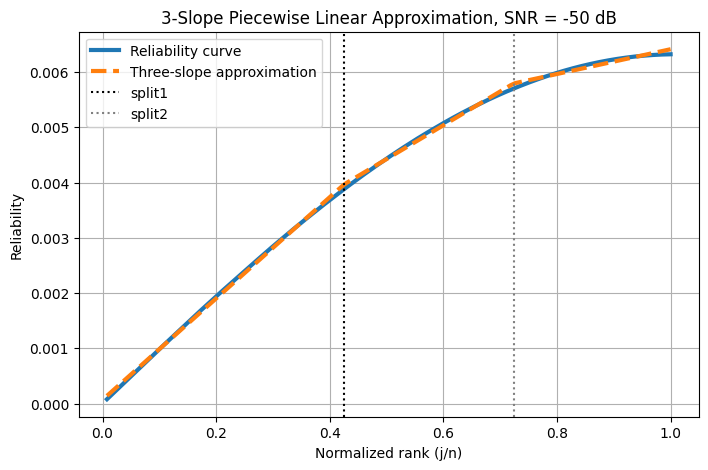

Best parameters
slope1 = 0.9193972721975496
slope2 = 0.6027622069867798
slope3 = 0.20948792906173103
split1 = 0.4118644067796611
split2 = 0.7237288135593221
SNR = -10
MSE = 0.002%


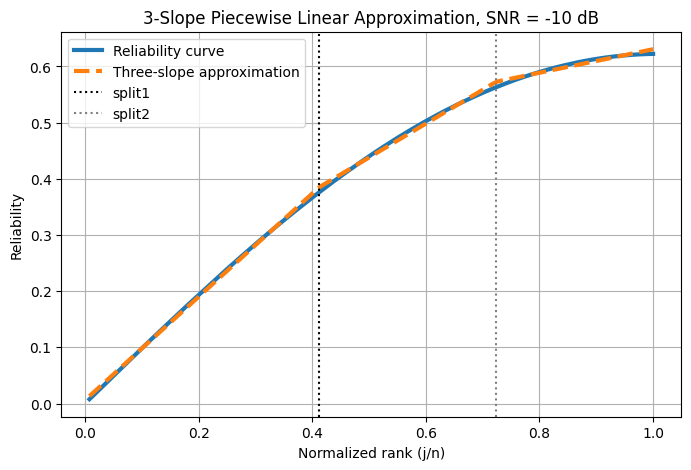

Best parameters
slope1 = 1.8129279894047885
slope2 = 1.1434752072164587
slope3 = 0.3942556129872151
split1 = 0.39830508474576276
split2 = 0.7101694915254237
SNR = -4
MSE = 0.006%


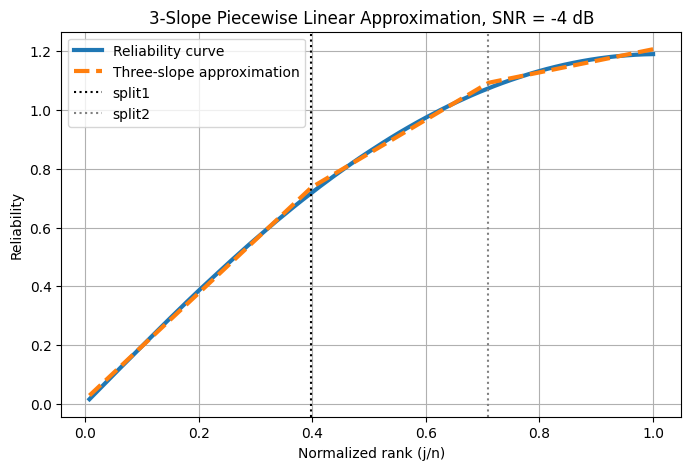

Best parameters
slope1 = 4.340042607480873
slope2 = 2.445790336544232
slope3 = 0.7976215603699541
split1 = 0.3305084745762712
split2 = 0.6423728813559323
SNR = 4
MSE = 0.043%


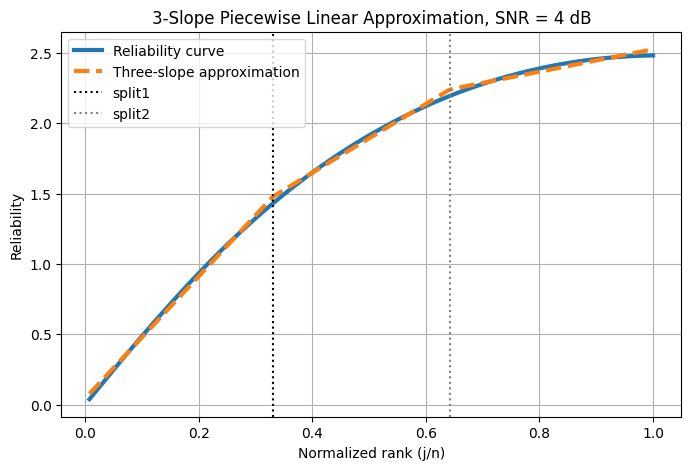

Best parameters
slope1 = 5.9790342707700415
slope2 = 3.0685730517902994
slope3 = 0.9201189731145365
split1 = 0.28983050847457625
split2 = 0.6152542372881357
SNR = 7
MSE = 0.084%


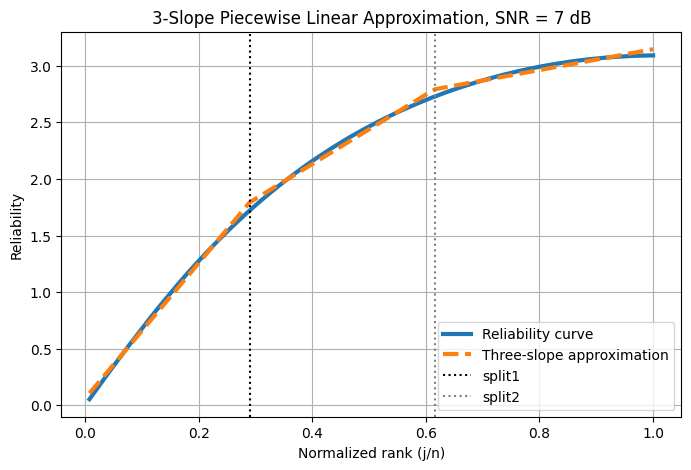

Best parameters
slope1 = 7.96493736109741
slope2 = 3.6261108630299868
slope3 = 1.0445431558444893
split1 = 0.2627118644067797
split2 = 0.588135593220339
SNR = 10
MSE = 0.151%


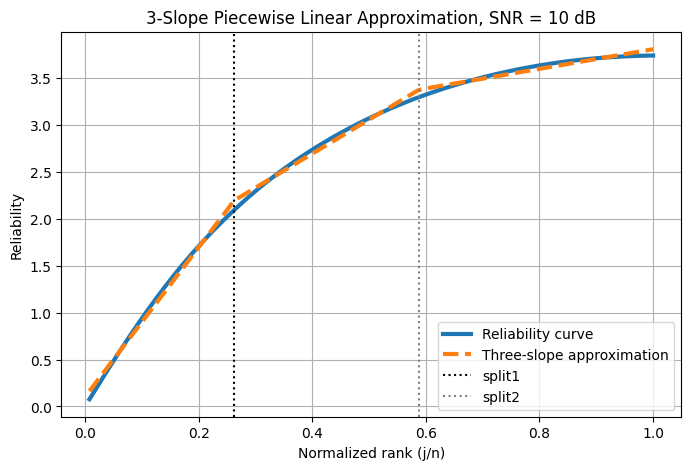

Best parameters
slope1 = 13.131028580834862
slope2 = 4.962172639181418
slope3 = 1.2787584808930044
split1 = 0.19491525423728814
split2 = 0.5203389830508475
SNR = 15
MSE = 0.349%


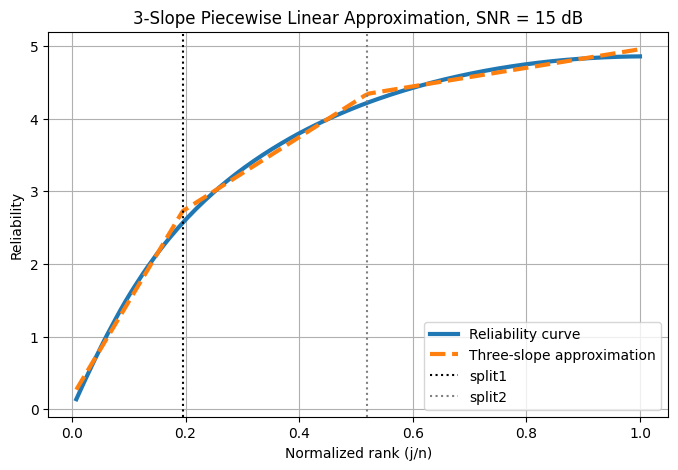

Best parameters
slope1 = 19.995462459809502
slope2 = 6.192459838040582
slope3 = 1.4828909342852743
split1 = 0.15423728813559323
split2 = 0.4661016949152543
SNR = 20
MSE = 0.673%


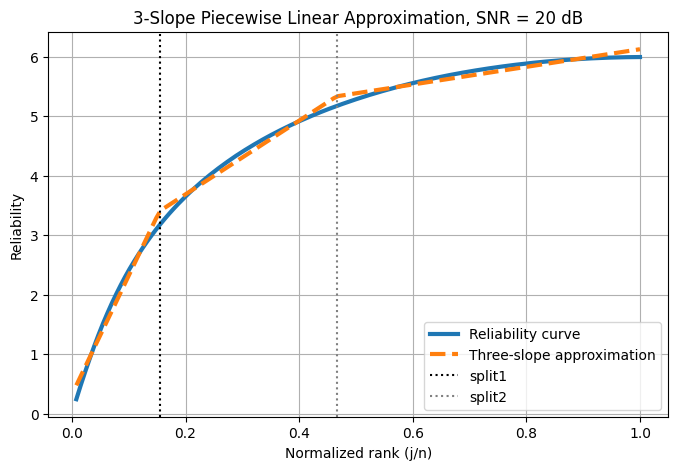

Best parameters
slope1 = 51.17478663226697
slope2 = 7.856378821891617
slope3 = 1.6797400126309974
split1 = 0.1
split2 = 0.4118644067796611
SNR = 50
MSE = 4.492%


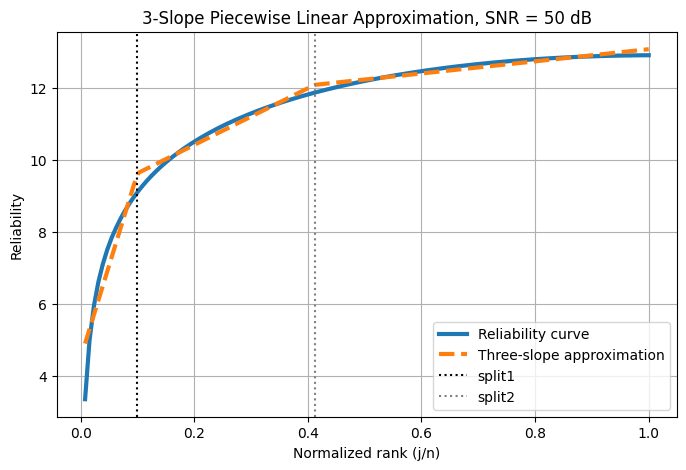

In [ ]:
# =========================================================================
# Three-Slope Continuous Piecewise Linear Fit
#
# PURPOSE:
#   Extends the two-slope model to two breakpoints t1 < t2, producing
#   three linear segments.  This better captures the Cauchy reliability
#   profile, which has a fast-rising section (low ranks), a transitional
#   section, and a flatter tail (high ranks, outlier-affected bits).
#
# MODEL (hinge representation):
#   y = b + c1*x + c2*max(0, x-t1) + c3*max(0, x-t2)
#   Effective slopes:
#     Slope 1 (x in [0,  t1]): c1
#     Slope 2 (x in [t1, t2]): c1 + c2
#     Slope 3 (x in [t2,  1]): c1 + c2 + c3
#
# BREAKPOINT SEARCH:
#   t1 and t2 are jointly scanned over a 60x60 grid in [0.1, 0.9]^2,
#   enforcing t2 > t1.  The pair minimising SSE is selected.
#   Complexity: O(60^2 * n) per SNR point.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Generate example Cauchy reliability curve
# -------------------------------------------------

def generate_cauchy_curve(n=128, Nframes=20000, snrdb=0):

    gamma = 10 ** (-snrdb / 20)

    x_bits = np.random.randint(0, 2, (n, Nframes))
    s = 1 - 2 * x_bits

    U = np.random.rand(n, Nframes)
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)

    Gamma = np.abs(LLR)

    Gamma_sorted = np.sort(Gamma, axis=0)

    y = np.mean(Gamma_sorted, axis=1)

    x = np.arange(1, n + 1) / n

    return x, y


# -------------------------------------------------
# Three-slope piecewise fit
# Continuous piecewise linear with 2 breakpoints
# -------------------------------------------------

def piecewise_fit_3slopes(x, y):

    best_sse = np.inf
    best_params = None

    t_values = np.linspace(0.1, 0.9, 60)

    for t1 in t_values:
        for t2 in t_values:

            if t2 <= t1:
                continue

            a1 = x
            a2 = np.maximum(0, x - t1)
            a3 = np.maximum(0, x - t2)

            A = np.column_stack([np.ones_like(x), a1, a2, a3])

            theta, _, _, _ = np.linalg.lstsq(A, y, rcond=None)

            b, c1, c2, c3 = theta

            yhat = A @ theta
            sse = np.sum((y - yhat) ** 2)

            if sse < best_sse:
                best_sse = sse
                best_mse=best_sse/len(x)

                # actual slopes in each region
                slope1 = c1
                slope2 = c1 + c2
                slope3 = c1 + c2 + c3

                best_params = (b, slope1, slope2, slope3, t1, t2, yhat, best_mse)

    return best_params


# -------------------------------------------------
# Run example
# -------------------------------------------------

for snrdb in [-50,-10,-4,4, 7, 10, 15, 20, 50]:
    x, y = generate_cauchy_curve(snrdb=snrdb)

    b, m1, m2, m3, t1, t2, yhat, best_mse = piecewise_fit_3slopes(x, y)

    print("Best parameters")
    print("slope1 =", m1)
    print("slope2 =", m2)
    print("slope3 =", m3)
    print("split1 =", t1)
    print("split2 =", t2)
    print("SNR =", snrdb)
    print(f"MSE = {best_mse*100:.3f}%")

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(x, y, label="Reliability curve", linewidth=3)
    plt.plot(x, yhat, '--', label="Three-slope approximation", linewidth=3)

    plt.axvline(t1, color='black', linestyle=':', label="split1")
    plt.axvline(t2, color='gray', linestyle=':', label="split2")

    plt.xlabel("Normalized rank (j/n)")
    plt.ylabel("Reliability")
    plt.legend()
    plt.grid()
    plt.title(f"3-Slope Piecewise Linear Approximation, SNR = {snrdb} dB")

    plt.show()

## Using Max Value Error


Best parameters
SNR = 4
slope1 = 4.322298707532638
slope2 = 2.460930320474838
slope3 = 0.7996562072500084
split1 = 0.3305084745762712
split2 = 0.6423728813559323
max abs error = 0.03427843197914999


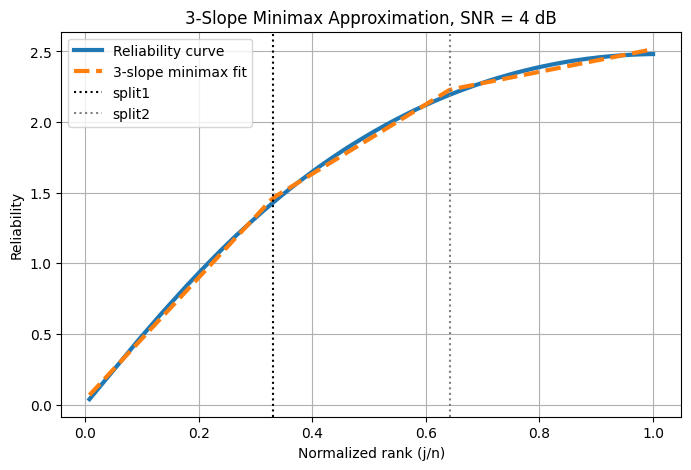


Best parameters
SNR = 7
slope1 = 5.9192596771571075
slope2 = 3.1437012815546086
slope3 = 0.9805305625732781
split1 = 0.28983050847457625
split2 = 0.6016949152542374
max abs error = 0.04821302799627415


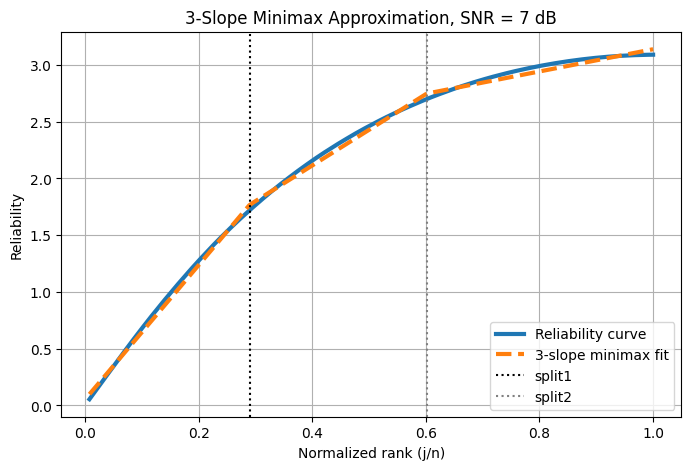


Best parameters
SNR = 10
slope1 = 8.040030029252605
slope2 = 3.9009032255280243
slope3 = 1.132437448403941
split1 = 0.24915254237288137
split2 = 0.5610169491525424
max abs error = 0.0645321020641816


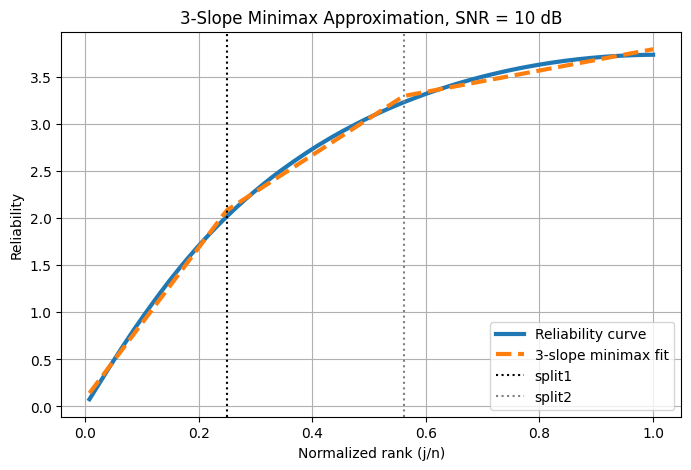


Best parameters
SNR = 15
slope1 = 13.419514049307857
slope2 = 5.537634342431382
slope3 = 1.4507407154521896
split1 = 0.18135593220338986
split2 = 0.47966101694915253
max abs error = 0.10077517776451236


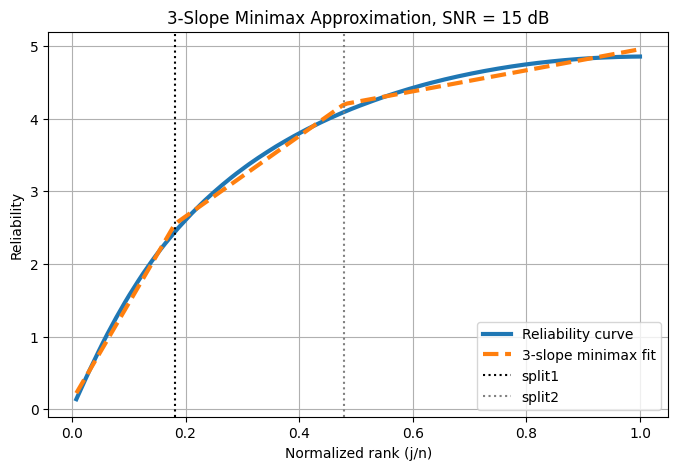


Best parameters
SNR = 20
slope1 = 22.542029766846436
slope2 = 7.640064527786924
slope3 = 1.8066083941227333
split1 = 0.1271186440677966
split2 = 0.39830508474576276
max abs error = 0.15057988291810648


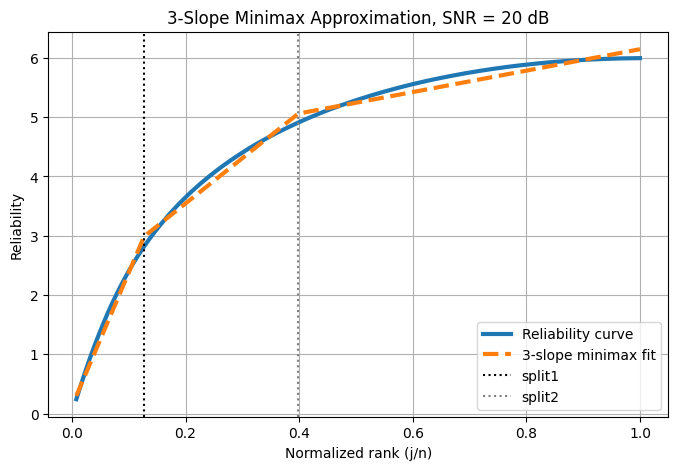

In [ ]:
# =========================================================================
# Three-Slope Minimax (L-infinity) Fit
#
# PURPOSE:
#   Unlike least-squares (which minimises mean squared error), the minimax
#   criterion minimises the MAXIMUM absolute error across all data points.
#   This produces a fit that guarantees a worst-case error bound — relevant
#   for hardware implementations where the maximum reliability error matters.
#
# OPTIMISATION FORMULATION:
#   For fixed breakpoints t1, t2, the minimax problem is reformulated as a
#   Linear Program (LP) by introducing a slack variable E (the worst-case
#   error) and encoding |y_i - yhat_i| <= E as two linear constraints per
#   point.  scipy.optimize.linprog with the 'highs' solver finds the optimal
#   coefficients [b, c1, c2, c3] and the optimal E.
#
# BREAKPOINT SEARCH:
#   Breakpoints are still scanned on a 60x60 grid; for each (t1,t2) pair,
#   one LP is solved.  The pair achieving the smallest optimal E is returned.
#
# COMPARISON TO LSQ:
#   The minimax fit may have higher MSE than the least-squares fit, but
#   its worst-case error will be lower.  Comparing the two reveals the
#   trade-off between average and worst-case approximation quality.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# -------------------------------------------------
# Generate example Cauchy reliability curve
# -------------------------------------------------

def generate_cauchy_curve(n=128, Nframes=20000, snrdb=0):

    gamma = 10 ** (-snrdb / 20)

    x_bits = np.random.randint(0, 2, (n, Nframes))
    s = 1 - 2 * x_bits

    U = np.random.rand(n, Nframes)
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)

    Gamma = np.abs(LLR)
    Gamma_sorted = np.sort(Gamma, axis=0)

    y = np.mean(Gamma_sorted, axis=1)
    x = np.arange(1, n + 1) / n

    return x, y


# -------------------------------------------------
# Solve minimax fit for fixed breakpoints
# Model:
# yhat = b + c1*x + c2*max(0,x-t1) + c3*max(0,x-t2)
# Minimize max_i |y_i - yhat_i|
# -------------------------------------------------

def minimax_fit_fixed_breaks(x, y, t1, t2):

    a1 = x
    a2 = np.maximum(0, x - t1)
    a3 = np.maximum(0, x - t2)

    A = np.column_stack([np.ones_like(x), a1, a2, a3])

    n = len(x)

    # Variables are [b, c1, c2, c3, E]
    # Objective: minimize E
    c = np.array([0, 0, 0, 0, 1], dtype=float)

    # Constraints:
    # y - A theta <= E   ->   -A theta - E <= -y
    # A theta - y <= E   ->    A theta - E <= y

    A_ub_1 = np.column_stack([ A, -np.ones(n)])
    b_ub_1 = y

    A_ub_2 = np.column_stack([-A, -np.ones(n)])
    b_ub_2 = -y

    A_ub = np.vstack([A_ub_1, A_ub_2])
    b_ub = np.concatenate([b_ub_1, b_ub_2])

    # E >= 0 ; other vars free
    bounds = [
        (None, None),  # b
        (None, None),  # c1
        (None, None),  # c2
        (None, None),  # c3
        (0, None)      # E
    ]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

    if not res.success:
        return None

    b, c1, c2, c3, E = res.x
    yhat = A @ np.array([b, c1, c2, c3])

    slope1 = c1
    slope2 = c1 + c2
    slope3 = c1 + c2 + c3

    return {
        "b": b,
        "c1": c1,
        "c2": c2,
        "c3": c3,
        "slope1": slope1,
        "slope2": slope2,
        "slope3": slope3,
        "t1": t1,
        "t2": t2,
        "E": E,
        "yhat": yhat
    }


# -------------------------------------------------
# Search over breakpoints
# -------------------------------------------------

def piecewise_fit_3slopes_minimax(x, y):

    best_E = np.inf
    best_params = None

    t_values = np.linspace(0.1, 0.9, 60)

    for t1 in t_values:
        for t2 in t_values:

            if t2 <= t1:
                continue

            result = minimax_fit_fixed_breaks(x, y, t1, t2)

            if result is None:
                continue

            if result["E"] < best_E:
                best_E = result["E"]
                best_params = result

    return best_params


# -------------------------------------------------
# Run example
# -------------------------------------------------

for snrdb in [4, 7, 10, 15, 20]:

    x, y = generate_cauchy_curve(snrdb=snrdb)

    result = piecewise_fit_3slopes_minimax(x, y)

    print("\nBest parameters")
    print("SNR =", snrdb)
    print("slope1 =", result["slope1"])
    print("slope2 =", result["slope2"])
    print("slope3 =", result["slope3"])
    print("split1 =", result["t1"])
    print("split2 =", result["t2"])
    print("max abs error =", result["E"])

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label="Reliability curve", linewidth=3)
    plt.plot(x, result["yhat"], '--', label="3-slope minimax fit", linewidth=3)
    plt.axvline(result["t1"], color='black', linestyle=':', label="split1")
    plt.axvline(result["t2"], color='gray', linestyle=':', label="split2")
    plt.xlabel("Normalized rank (j/n)")
    plt.ylabel("Reliability")
    plt.title(f"3-Slope Minimax Approximation, SNR = {snrdb} dB")
    plt.grid()
    plt.legend()
    plt.show()

##Four_slope piecewise fit



Best parameters
SNR = 4
slope1 = 4.5342494111249305
slope2 = 3.0448901598527165
slope3 = 1.732102678448602
slope4 = 0.5998781612074329
split1 = 0.2647058823529412
split2 = 0.5
split3 = 0.7352941176470588
MSE = 0.00013266923989857206


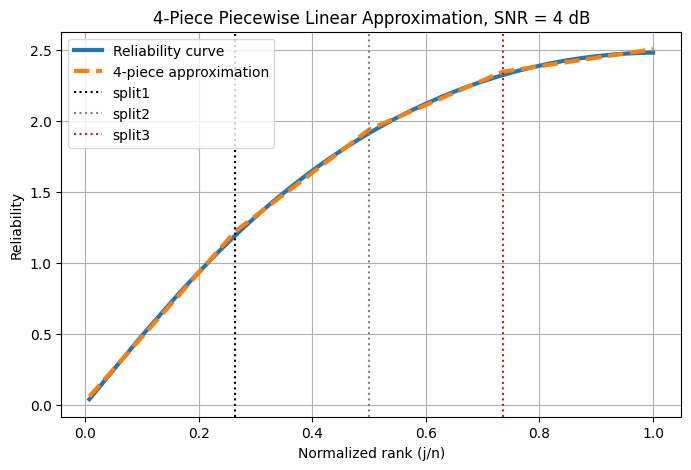


Best parameters
SNR = 7
slope1 = 6.189827503149507
slope2 = 3.917483375287439
slope3 = 2.153291648760532
slope4 = 0.6907911197815151
split1 = 0.2411764705882353
split2 = 0.4529411764705882
split3 = 0.711764705882353
MSE = 0.00026350769967800223


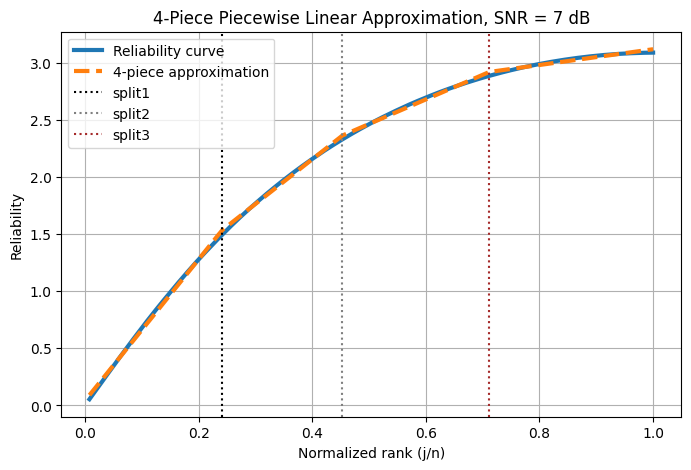


Best parameters
SNR = 10
slope1 = 8.60353980720076
slope2 = 5.136253654821546
slope3 = 2.5603433301011447
slope4 = 0.7740950788115741
split1 = 0.19411764705882353
split2 = 0.40588235294117647
split3 = 0.6882352941176471
MSE = 0.0004762854888902587


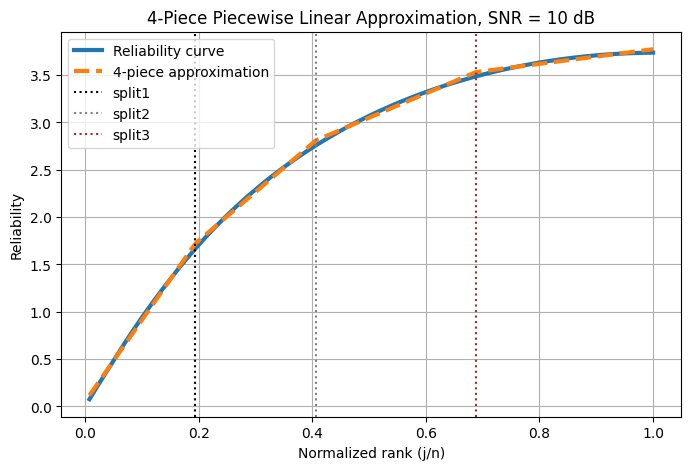


Best parameters
SNR = 15
slope1 = 14.286170269622481
slope2 = 7.28045488611982
slope3 = 3.3872501439147276
slope4 = 1.0162422021781152
split1 = 0.14705882352941177
split2 = 0.33529411764705885
split3 = 0.6176470588235293
MSE = 0.0010925902987686128


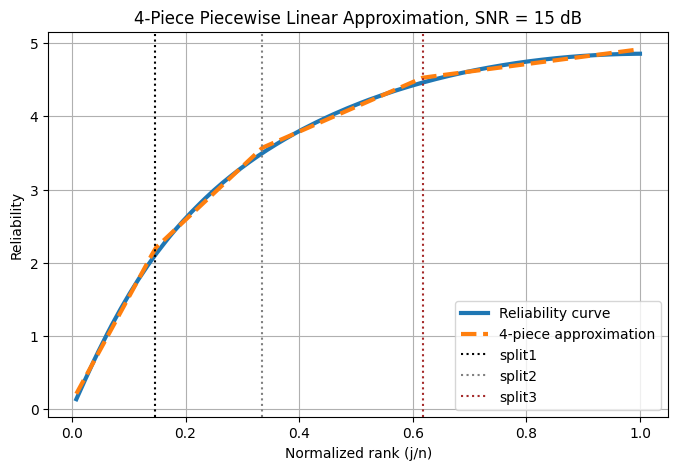


Best parameters
SNR = 20
slope1 = 21.841417105030978
slope2 = 8.783982532077083
slope3 = 3.5826251140776666
slope4 = 1.0034006198706051
split1 = 0.12352941176470589
split2 = 0.31176470588235294
split3 = 0.6176470588235293
MSE = 0.002203865497920612


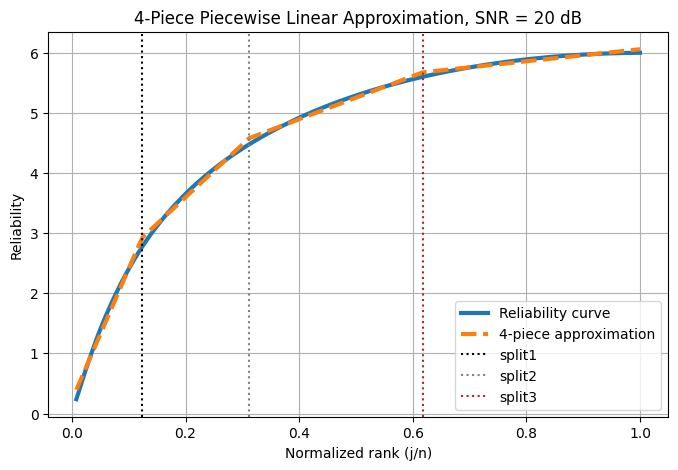


Best parameters
SNR = 50
slope1 = 50.02967835688357
slope2 = 9.053793924034842
slope3 = 3.7957555768327715
slope4 = 1.112775458782565
split1 = 0.1
split2 = 0.31176470588235294
split3 = 0.5941176470588235
MSE = 0.03860812110773301


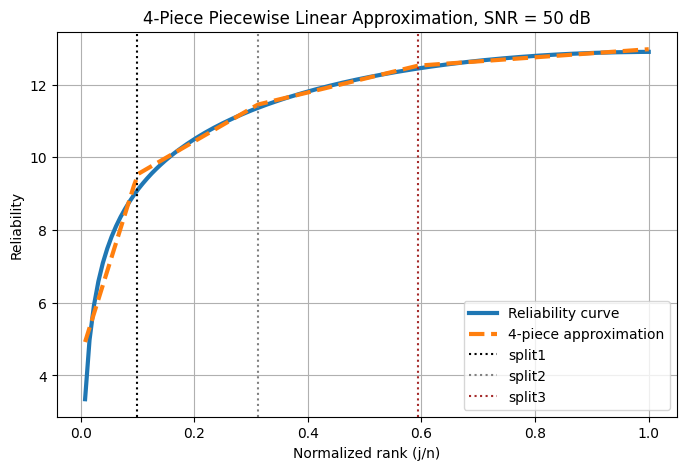


Best parameters
SNR = 100
slope1 = 51.49125563105343
slope2 = 8.932948211604604
slope3 = 3.8121873259033983
slope4 = 1.109068759082965
split1 = 0.1
split2 = 0.31176470588235294
split3 = 0.5941176470588235
MSE = 0.050423903536422024


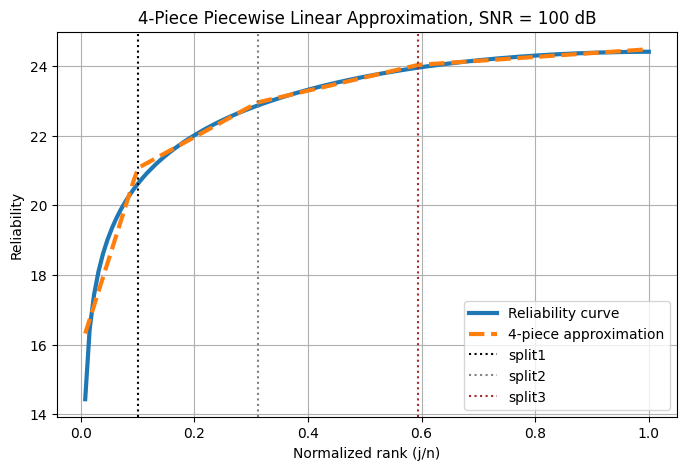

In [ ]:
# =========================================================================
# Four-Slope Continuous Piecewise Linear Fit
#
# PURPOSE:
#   Adds a third breakpoint t3 (so t1 < t2 < t3) for four linear segments.
#   The additional segment can capture fine structure in the reliability
#   profile such as the outlier shoulder visible at high noise levels.
#
# MODEL (hinge representation):
#   y = b + c1*x + c2*max(0,x-t1) + c3*max(0,x-t2) + c4*max(0,x-t3)
#   Effective slopes:
#     Segment 1 [0,  t1]: c1
#     Segment 2 [t1, t2]: c1+c2
#     Segment 3 [t2, t3]: c1+c2+c3
#     Segment 4 [t3,  1]: c1+c2+c3+c4
#
# BREAKPOINT SEARCH:
#   t1, t2, t3 are jointly scanned over a 35x35x35 grid (~42k iterations).
#   Increase the grid resolution for finer breakpoint precision at the cost
#   of longer runtime.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Generate example Cauchy reliability curve
# -------------------------------------------------

def generate_cauchy_curve(n=128, Nframes=20000, snrdb=0):

    gamma = 10 ** (-snrdb / 20)

    x_bits = np.random.randint(0, 2, (n, Nframes))
    s = 1 - 2 * x_bits

    U = np.random.rand(n, Nframes)
    z = gamma * np.tan(np.pi * (U - 0.5))
    r = s + z

    LLR = np.log(1 + ((r - 1) / gamma) ** 2) - np.log(1 + ((r + 1) / gamma) ** 2)

    Gamma = np.abs(LLR)
    Gamma_sorted = np.sort(Gamma, axis=0)

    y = np.mean(Gamma_sorted, axis=1)
    x = np.arange(1, n + 1) / n

    return x, y


# -------------------------------------------------
# Four-piece continuous piecewise linear fit
# -------------------------------------------------

def piecewise_fit_4pieces(x, y):

    best_sse = np.inf
    best_params = None

    t_values = np.linspace(0.1, 0.9, 35)   # can increase for finer search

    for t1 in t_values:
        for t2 in t_values:
            for t3 in t_values:

                if not (t1 < t2 < t3):
                    continue

                a1 = x
                a2 = np.maximum(0, x - t1)
                a3 = np.maximum(0, x - t2)
                a4 = np.maximum(0, x - t3)

                A = np.column_stack([np.ones_like(x), a1, a2, a3, a4])

                theta, _, _, _ = np.linalg.lstsq(A, y, rcond=None)

                b, c1, c2, c3, c4 = theta
                yhat = A @ theta

                sse = np.sum((y - yhat) ** 2)

                if sse < best_sse:
                    best_sse = sse

                    m1 = c1
                    m2 = c1 + c2
                    m3 = c1 + c2 + c3
                    m4 = c1 + c2 + c3 + c4

                    best_params = {
                        "b": b,
                        "c1": c1,
                        "c2": c2,
                        "c3": c3,
                        "c4": c4,
                        "slope1": m1,
                        "slope2": m2,
                        "slope3": m3,
                        "slope4": m4,
                        "t1": t1,
                        "t2": t2,
                        "t3": t3,
                        "yhat": yhat,
                        "sse": sse,
                        "mse": sse / len(x)
                    }

    return best_params


# -------------------------------------------------
# Run example
# -------------------------------------------------

for snrdb in [4, 7, 10, 15, 20, 50, 100]:

    x, y = generate_cauchy_curve(snrdb=snrdb)

    result = piecewise_fit_4pieces(x, y)

    print("\nBest parameters")
    print("SNR =", snrdb)
    print("slope1 =", result["slope1"])
    print("slope2 =", result["slope2"])
    print("slope3 =", result["slope3"])
    print("slope4 =", result["slope4"])
    print("split1 =", result["t1"])
    print("split2 =", result["t2"])
    print("split3 =", result["t3"])
    print("MSE =", result["mse"])

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, label="Reliability curve", linewidth=3)
    plt.plot(x, result["yhat"], '--', label="4-piece approximation", linewidth=3)

    plt.axvline(result["t1"], color='black', linestyle=':', label="split1")
    plt.axvline(result["t2"], color='gray', linestyle=':', label="split2")
    plt.axvline(result["t3"], color='brown', linestyle=':', label="split3")

    plt.xlabel("Normalized rank (j/n)")
    plt.ylabel("Reliability")
    plt.title(f"4-Piece Piecewise Linear Approximation, SNR = {snrdb} dB")
    plt.grid()
    plt.legend()
    plt.show()

#Reliability Curve

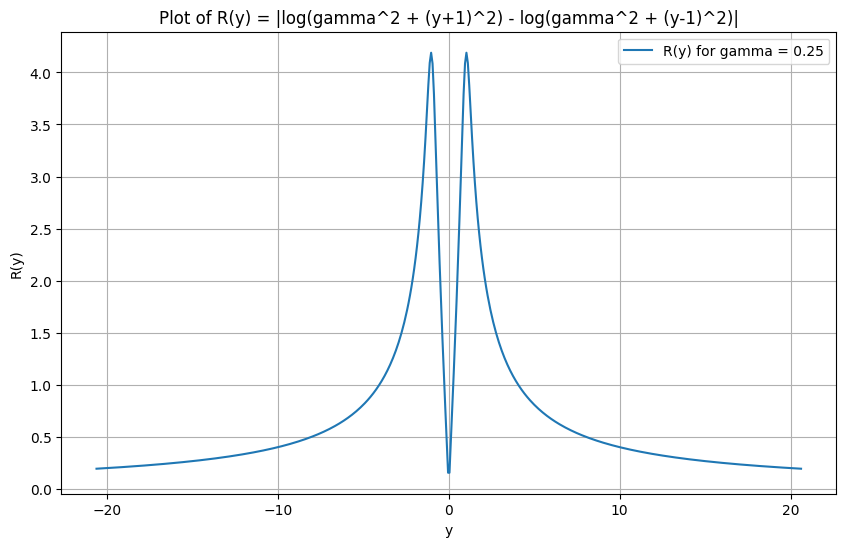

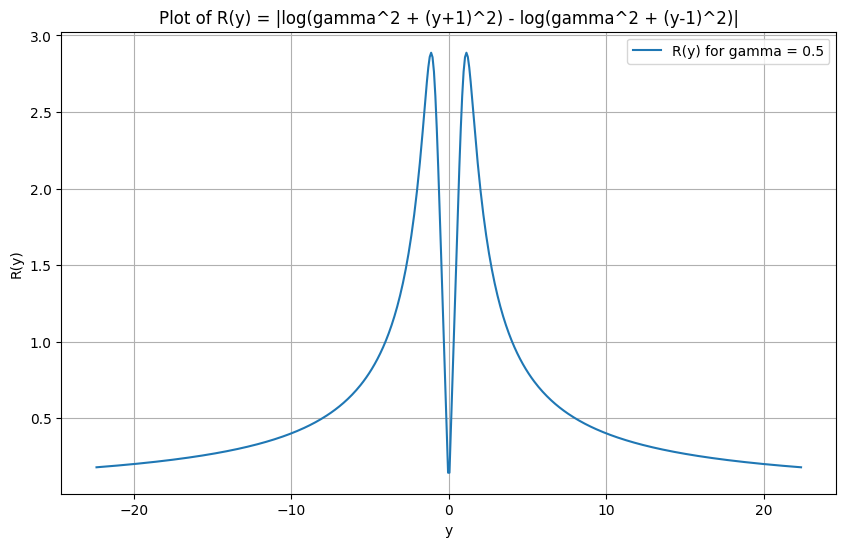

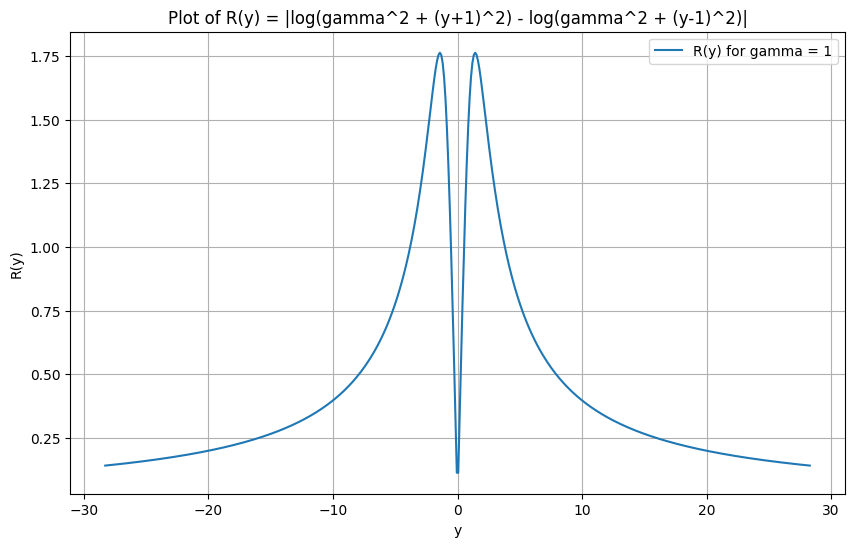

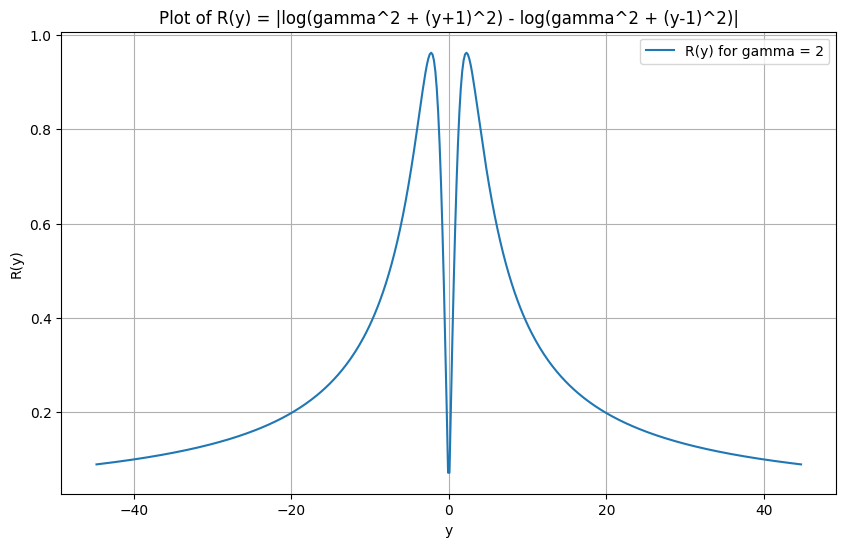

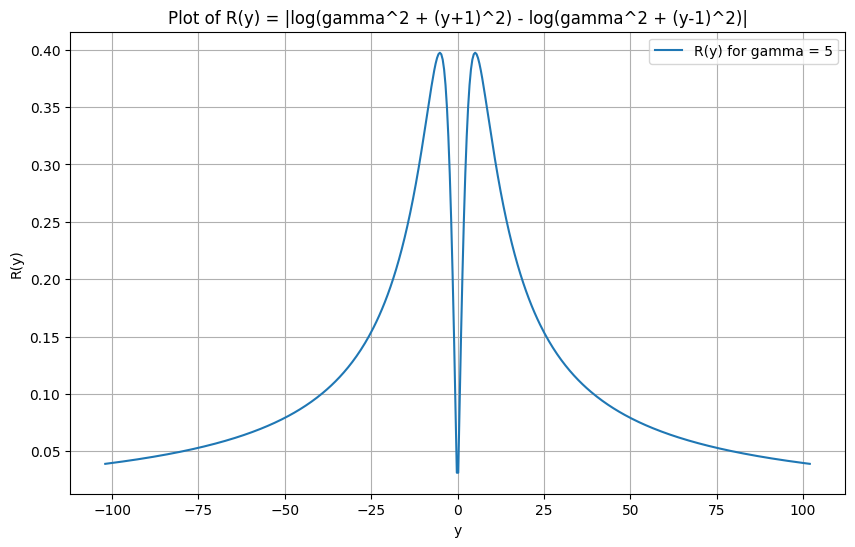

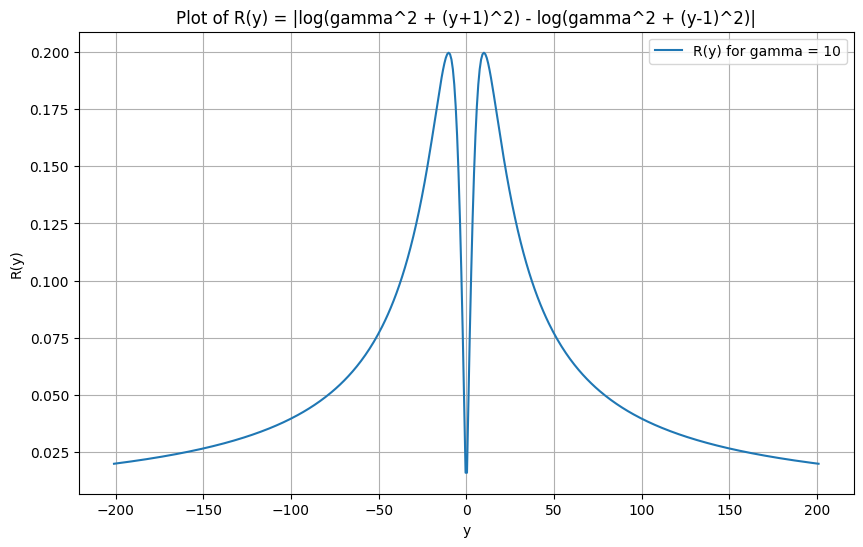

##Three piecewise fit - Gemini Code

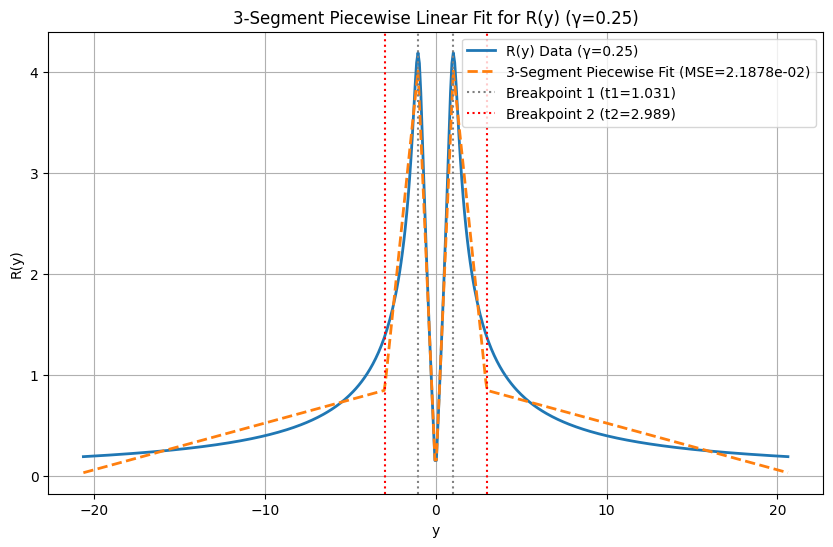


Gamma = 0.25
  First fixed breakpoint t1 = 1.0308
  Optimal second breakpoint t2 = 2.9893
  Segment 1 slope (0 to t1) = 3.8928
  Segment 2 slope (t1 to t2) = -1.6148
  Segment 3 slope (t2 onwards) = -0.0462
  Minimum MSE = 2.1878e-02


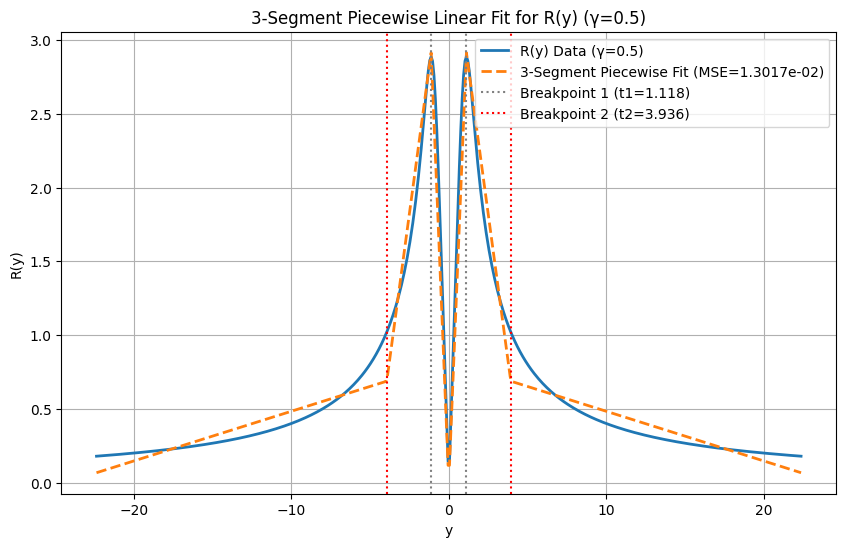


Gamma = 0.5
  First fixed breakpoint t1 = 1.1180
  Optimal second breakpoint t2 = 3.9359
  Segment 1 slope (0 to t1) = 2.6081
  Segment 2 slope (t1 to t2) = -0.7908
  Segment 3 slope (t2 onwards) = -0.0337
  Minimum MSE = 1.3017e-02


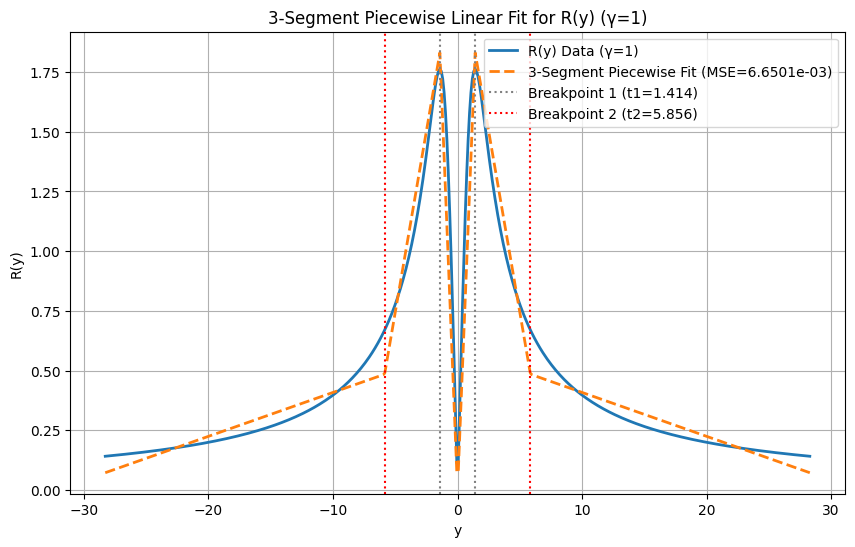


Gamma = 1
  First fixed breakpoint t1 = 1.4142
  Optimal second breakpoint t2 = 5.8560
  Segment 1 slope (0 to t1) = 1.2953
  Segment 2 slope (t1 to t2) = -0.3033
  Segment 3 slope (t2 onwards) = -0.0184
  Minimum MSE = 6.6501e-03


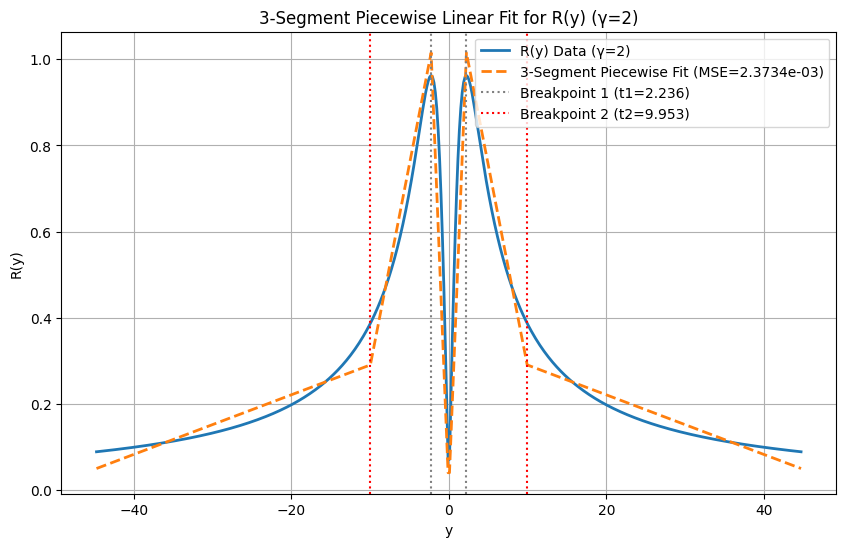


Gamma = 2
  First fixed breakpoint t1 = 2.2361
  Optimal second breakpoint t2 = 9.9528
  Segment 1 slope (0 to t1) = 0.4542
  Segment 2 slope (t1 to t2) = -0.0939
  Segment 3 slope (t2 onwards) = -0.0069
  Minimum MSE = 2.3734e-03


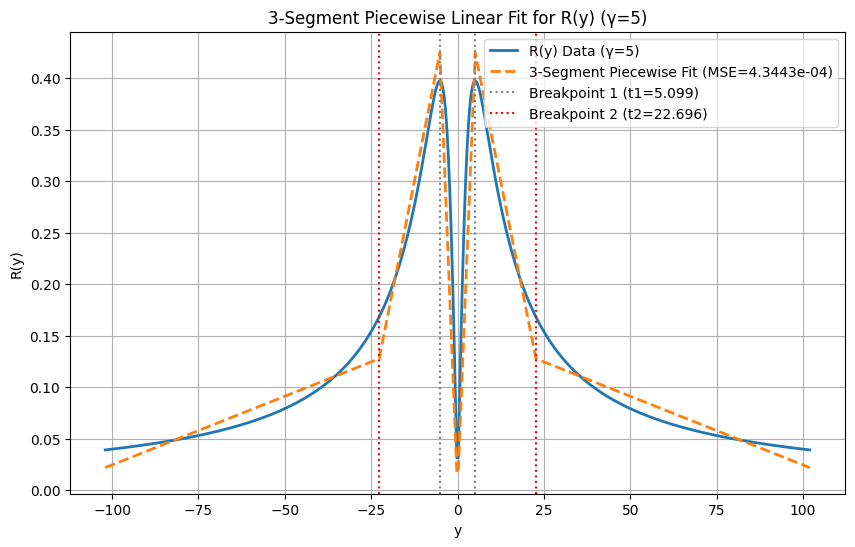


Gamma = 5
  First fixed breakpoint t1 = 5.0990
  Optimal second breakpoint t2 = 22.6958
  Segment 1 slope (0 to t1) = 0.0833
  Segment 2 slope (t1 to t2) = -0.0169
  Segment 3 slope (t2 onwards) = -0.0013
  Minimum MSE = 4.3443e-04


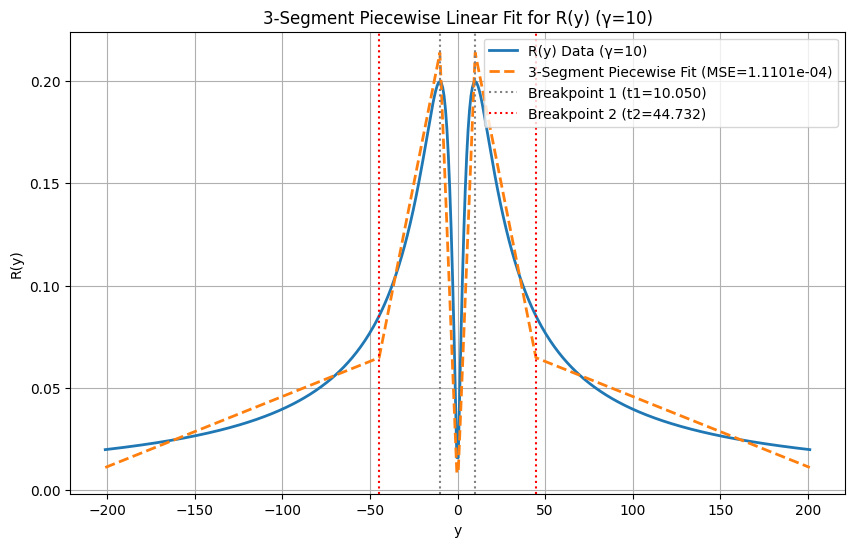


Gamma = 10
  First fixed breakpoint t1 = 10.0499
  Optimal second breakpoint t2 = 44.7322
  Segment 1 slope (0 to t1) = 0.0213
  Segment 2 slope (t1 to t2) = -0.0043
  Segment 3 slope (t2 onwards) = -0.0003
  Minimum MSE = 1.1101e-04


##Three piecewise fit - ChatGPT

=== 3-piece fit results ===
gamma   = 0.5
y0      = 1.118034
y_split = 1.846462
m1      = 2.977360
m2      = -1.836687
m3      = -0.509696
b2      = 5.382269
b3      = 2.932029
MSE     = 1.27690759e-02


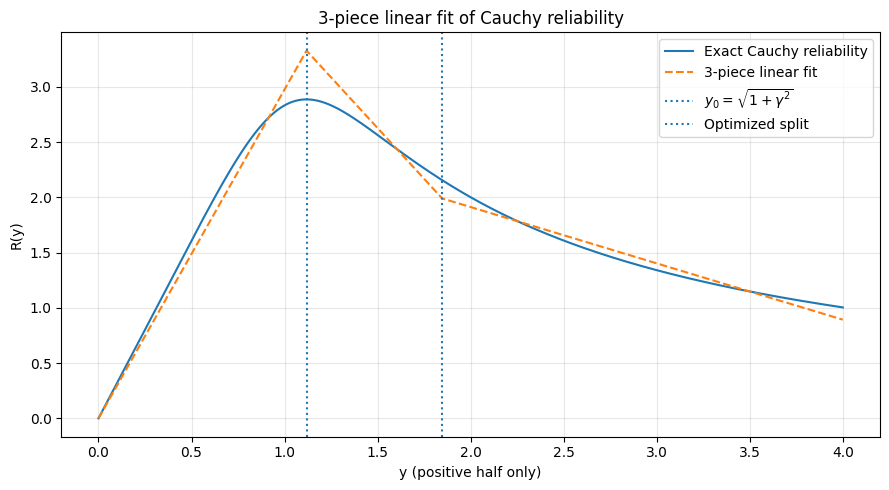